# Import/Setup


In [ ]:
pip install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 75.3 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
pip install -U umap-learn

In [ ]:
pip install pot

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 29.1 MB/s eta 0:00:00


In [ ]:
from pathlib import Path

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from tqdm.notebook import tqdm as tqdm

In [ ]:
import ot

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

In [ ]:

os.chdir('/content/drive/MyDrive/mAD Dataset')

#Initialize

In [ ]:
import numpy as np
import pandas as pd
import sklearn
import umap
import scipy
import matplotlib.pyplot as plt

In [ ]:
import sklearn
from sklearn import preprocessing
from sklearn import decomposition

In [ ]:
import pandas as pd

In [ ]:
xmatd = pd.read_csv("xmat_disease.csv", index_col =0)

In [ ]:
xmatc = pd.read_csv("xmat_control.csv", index_col =0)

In [ ]:
metad = pd.read_csv("meta_disease.csv", index_col = 0)

In [ ]:
xmatd = xmatd.drop(labels = ["id","GENE"], axis = 1)

In [ ]:
metad = metad.drop(labels = ["id"], axis = 1)

In [ ]:

metac = pd.read_csv("meta_control.csv", index_col = 0)

In [ ]:
metac = metac.drop(labels = ["id"], axis = 1)

In [ ]:
xp = pd.read_csv("latent_v9.csv")

In [ ]:
xp = xp.drop(labels = ["Unnamed: 0"], axis = 1)

In [ ]:
xs = xp.copy()

In [ ]:
xs = xs.loc[:, (xp != 0).any(axis=0)]

In [ ]:
xs.index = list(xmatd.index) + list(xmatc.index)

In [ ]:
xpd = xs.loc[xmatd.index]

In [ ]:
xpc = xs.loc[xmatc.index]

In [ ]:
xs = xpd[(metad['timepoint'] == 0)]
xt = xpd[(metad['timepoint'] == 1)]

In [ ]:
xs_c = xpc[metac['timepoint'] == 0]
xt_c = xpc[metac['timepoint'] == 1]

# Optimal Transport

In [ ]:
a, b = np.ones((xs.shape[0],)) / xs.shape[0], np.ones((xt.shape[0],)) / xt.shape[0]

In [ ]:
xs = np.array(xs)

In [ ]:
xt = np.array(xt)

In [ ]:
import numpy as np  # always need it
import pylab as pl  # do the plots

import ot  # ot

import time

In [ ]:
M = ot.dist(xs, xt)
M /= M.max()

KeyboardInterrupt: 

In [ ]:
M.shape

In [ ]:
#DO ON HIGH RAM
reg = 0.0005
reg_m_kl = 0.05

entropic_kl_uot = ot.unbalanced.sinkhorn_unbalanced(a, b, M, reg, reg_m_kl)

In [ ]:
ot = pd.DataFrame(entropic_kl_uot)

In [ ]:
import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)


In [ ]:
maps_8 = pd.DataFrame(ot.idxmax(axis = 1))

In [ ]:
maps_8.columns = ["13"]
maps_8["8"] = maps_8.index

In [ ]:
maps_13 = pd.DataFrame(ot.idxmax(axis = 0))

In [ ]:
maps_13.columns = ["8"]
maps_13["13"] = maps_13.index

In [ ]:
unique_values = maps_13["8"].unique()

# Create a range from 0 to 20005 and remove the unique values
remaining_values = set(range(18309)) - set(unique_values)

# Filter rows from maps_13 based on remaining values
filtered_rows = maps_8[maps_8["8"].isin(remaining_values)]

# Concatenate the filtered_rows with maps_8
concatenated_maps = pd.concat([maps_13, filtered_rows], ignore_index=True)

# Save the result to a new DataFrame named 'maps'
maps = concatenated_maps.copy()

In [ ]:
maps = maps.drop_duplicates()

In [ ]:
maps['weights'] = maps.apply(lambda row: ot.iloc[row['8'], row['13']], axis=1)

In [ ]:
bins = np.logspace(-10, -4, 200)

# Plot the distribution with custom binning
plt.hist(maps['weights'], bins=bins, color='skyblue')
plt.xscale('log')  # Use a logarithmic scale for better visibility
plt.title('Distribution of Transportation Matrix')
plt.xlabel('Weights')
plt.ylabel('Frequency')
plt.show()

# OT v2


In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

In [ ]:

os.chdir('/content/drive/MyDrive/mAD Dataset')

In [ ]:
dis_transmat = pd.read_csv("transmat-disease.csv", index_col = 0)
con_transmat = pd.read_csv("transmat-control.csv", index_col = 0)

In [ ]:

import io
import pandas as pd
order = pd.read_csv(io.StringIO('''
Micro1
Micro2
Micro3
Astro1
Astro2
Astro3
Oligo1
Oligo2
Oligo3
OPC
CTX-Ex1
CTX-Ex2
CTX-Ex3
CTX-Ex4
Cnr1
Lamp5
Pvalb
Sst
Vip
Pvalb_Nog
CA1-Ex
CA2-Ex
CA3-Ex
DG
LHb
Endo1
Endo2
Endo3
S1
S2
S3
S4
S5
'''), header=None)

In [ ]:
dis_transmat = dis_transmat.reindex(columns=order[0])
dis_transmat = dis_transmat.reindex(index=order[0])

In [ ]:
import pandas as pd
import numpy as np

# Define the top-level cell types and their subtypes
cell_types = {
    "CTX-Ex": ["CTX-Ex1", "CTX-Ex2", "CTX-Ex3", "CTX-Ex4"],
    "Inhi": ["Cnr1", "Lamp5", "Pvalb", "Sst", "Vip", "Pvalb_Nog"],
    "CA-Ex": ["CA1-Ex", "CA2-Ex", "CA3-Ex"],
    "DG": ["DG"],
    "Astro": ["Astro1", "Astro2", "Astro3"],
    "Endo": ["Endo1", "Endo2", "Endo3"],
    "Micro": ["Micro1", "Micro2", "Micro3"],
    "Oligo": ["Oligo1", "Oligo2", "Oligo3"],
    "SMC": ["S1", "S2", "S3", "S4", "S5"],
    "LHb": ["LHb"],
}

# Assuming dis_transmat is already loaded as a DataFrame
dis_transmat_param = pd.DataFrame(0, index=dis_transmat.index, columns=dis_transmat.columns)

for top_type, subtypes in cell_types.items():
    # Extract square matrix for the current top-level cell type
    submatrix = dis_transmat.loc[subtypes, subtypes].copy()

    # Normalize each column so that its sum is 1
    submatrix = submatrix.div(submatrix.sum(axis=1), axis=0).fillna(0)

    # Place the normalized submatrix into dis_transmat_param
    dis_transmat_param.loc[subtypes, subtypes] = submatrix

# dis_transmat_param now contains the properly normalized values


/tmp/ipython-input-949707779.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.53105103 0.18357992 0.17630596 0.19427644]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dis_transmat_param.loc[subtypes, subtypes] = submatrix
/tmp/ipython-input-949707779.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.07376765 0.37959634 0.09336067 0.08496879]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dis_transmat_param.loc[subtypes, subtypes] = submatrix
/tmp/ipython-input-949707779.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.16513068 0.23570346 0.51883802 0.17731996]' has dtype incompatible with int64, please explicitly cast to a compatible dt

In [ ]:
con_transmat = con_transmat.reindex(columns=order[0])
con_transmat = con_transmat.reindex(index=order[0])

In [ ]:
import pandas as pd
import numpy as np

# Define the top-level cell types and their subtypes
cell_types = {
    "CTX-Ex": ["CTX-Ex1", "CTX-Ex2", "CTX-Ex3", "CTX-Ex4"],
    "Inhi": ["Cnr1", "Lamp5", "Pvalb", "Sst", "Vip", "Pvalb_Nog"],
    "CA-Ex": ["CA1-Ex", "CA2-Ex", "CA3-Ex"],
    "DG": ["DG"],
    "Astro": ["Astro1", "Astro2", "Astro3"],
    "Endo": ["Endo1", "Endo2", "Endo3"],
    "Micro": ["Micro1", "Micro2", "Micro3"],
    "Oligo": ["Oligo1", "Oligo2", "Oligo3"],
    "SMC": ["S1", "S2", "S3", "S4", "S5"],
    "LHb": ["LHb"],
}

# Assuming dis_transmat is already loaded as a DataFrame
con_transmat_param = pd.DataFrame(0, index=con_transmat.index, columns=con_transmat.columns)

for top_type, subtypes in cell_types.items():
    # Extract square matrix for the current top-level cell type
    submatrix = con_transmat.loc[subtypes, subtypes].copy()

    # Normalize each column so that its sum is 1
    submatrix = submatrix.div(submatrix.sum(axis=1), axis=0).fillna(0)

    # Place the normalized submatrix into dis_transmat_param
    con_transmat_param.loc[subtypes, subtypes] = submatrix

# con_transmat_param now contains the properly normalized values


/tmp/ipython-input-39471389.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.51029534 0.18840988 0.22007667 0.26516991]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  con_transmat_param.loc[subtypes, subtypes] = submatrix
/tmp/ipython-input-39471389.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.16876373 0.53499746 0.16816663 0.17277763]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  con_transmat_param.loc[subtypes, subtypes] = submatrix
/tmp/ipython-input-39471389.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.1660407  0.17391877 0.44796057 0.21039342]' has dtype incompatible with int64, please explicitly cast to a compatible dtype

In [ ]:

param_transmat = dis_transmat_param - con_transmat_param

In [ ]:
param_transmat = param_transmat.reindex(columns=order[0])
param_transmat = param_transmat.reindex(index=order[0])

In [ ]:
inhi_mapping = {
    "Cnr1": "Inhi1",
    "Lamp5": "Inhi2",
    "Pvalb": "Inhi3",
    "Sst": "Inhi4",
    "Vip": "Inhi5",
    "Pvalb_Nog": "Inhi6"
}

# Replace in both index and columns
dis_transmat_param.rename(index=inhi_mapping, columns=inhi_mapping, inplace=True)
con_transmat_param.rename(index=inhi_mapping, columns=inhi_mapping, inplace=True)
param_transmat.rename(index=inhi_mapping, columns=inhi_mapping, inplace=True)

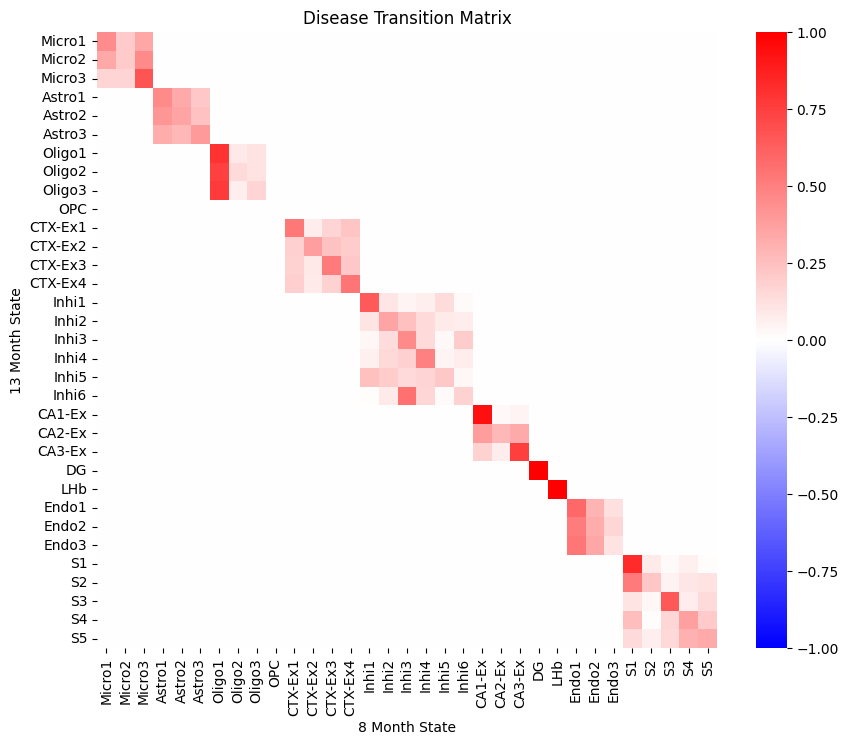

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))  # Adjust size as necessary
sns.heatmap(dis_transmat_param, cmap="bwr", cbar=True, vmin = -1, vmax = 1, xticklabels=True, yticklabels=True)

# Add labels
plt.title("Disease Transition Matrix")
plt.xlabel("8 Month State")
plt.ylabel("13 Month State")

# Show the plot
plt.show()

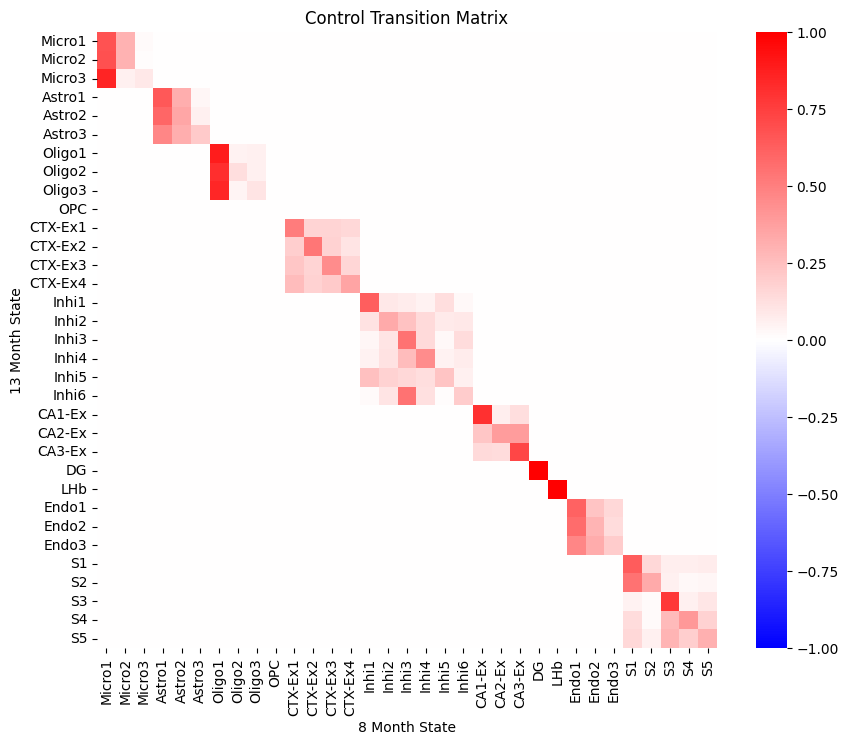

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 8))  # Adjust size as necessary
sns.heatmap(con_transmat_param, cmap="bwr", cbar=True, vmin = -1, vmax = 1, xticklabels=True, yticklabels=True)

# Add labels
plt.title("Control Transition Matrix")
plt.xlabel("8 Month State")
plt.ylabel("13 Month State")

# Show the plot
plt.show()

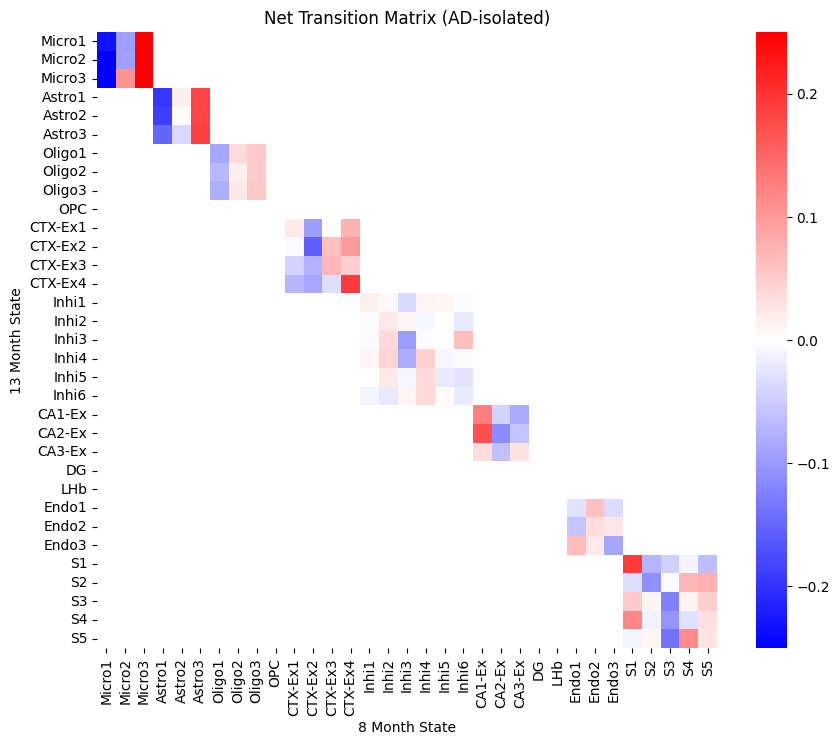

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 8))  # Adjust size as necessary
sns.heatmap(param_transmat, cmap="bwr", cbar=True, vmin = -0.25, vmax = 0.25, xticklabels=True, yticklabels=True)

# Add labels
plt.title("Net Transition Matrix (AD-isolated)")
plt.xlabel("8 Month State")
plt.ylabel("13 Month State")

# Show the plot
plt.show()

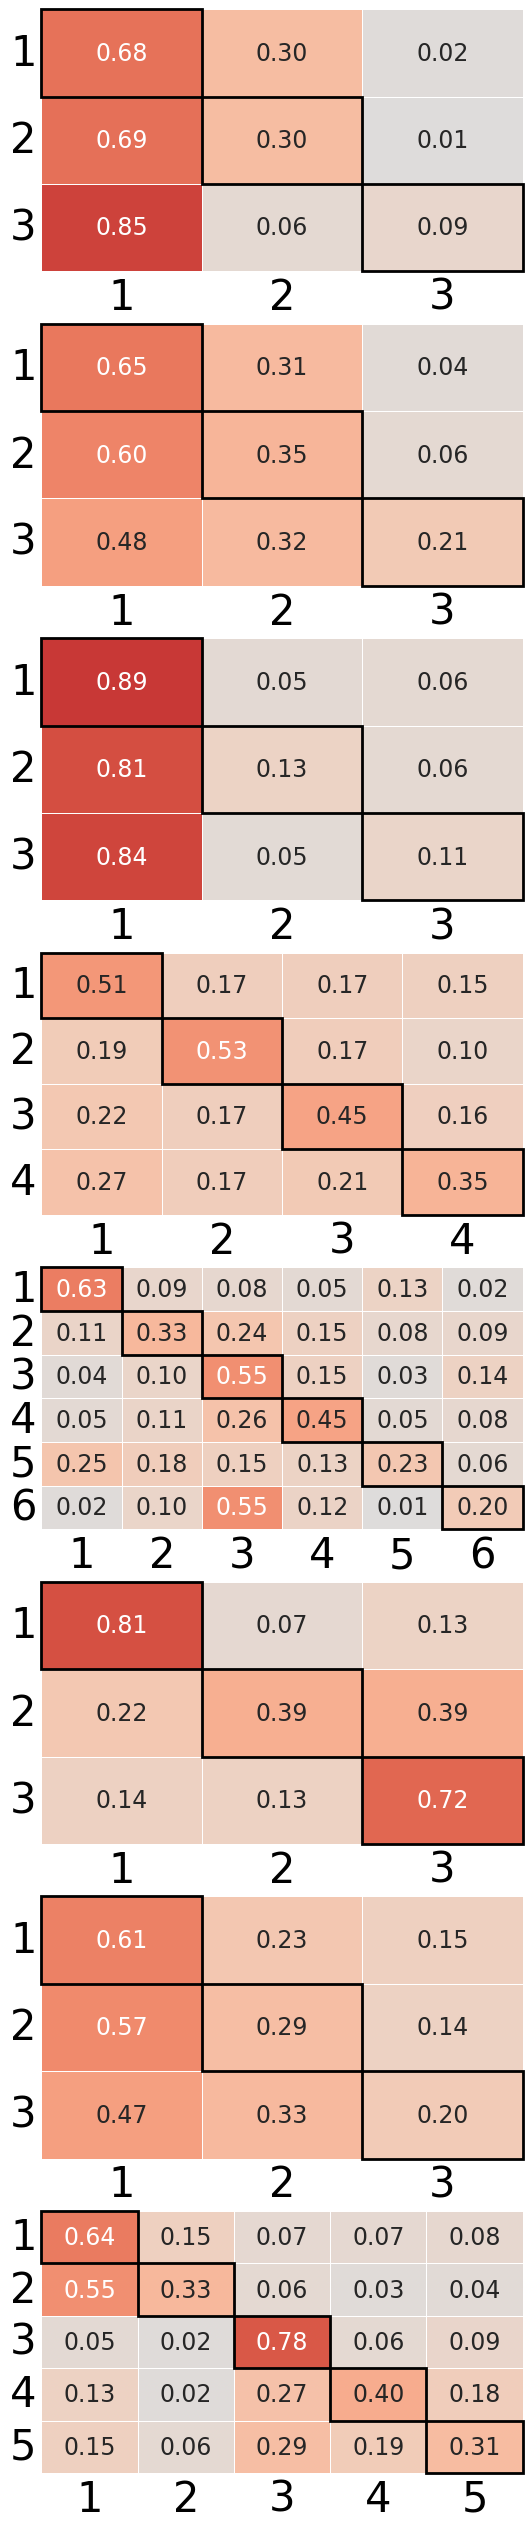

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import label
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches

def extract_connected_components(matrix):
    labeled_matrix, num_components = label(matrix != 0)
    components = []
    for label_id in range(1, num_components + 1):
        component_mask = labeled_matrix == label_id
        component_matrix = matrix * component_mask
        component_matrix = component_matrix[component_matrix != 0]
        components.append(component_matrix)
    return components

# Example DataFrame
trans = con_transmat_param  # Replace with your DataFrame
trans = trans.drop(index=['DG', 'LHb', "OPC"], columns=['DG', 'LHb', "OPC"])

components = extract_connected_components(trans.to_numpy())

fig = plt.figure(figsize=(7, 4 * len(components)))
gs = gridspec.GridSpec(len(components), 2, width_ratios=[2.5, 0.25], wspace=0.05)

plt.rcParams.update({'font.size': 17})

s = 0

for index, component in enumerate(components):
    if len(component) == 1:
        continue

    size = int(np.sqrt(len(component)))
    reshaped_component = component[:size*size].reshape((size, size))

    component_indices = list(trans.index[s:s+size])

    ax_matrix = plt.subplot(gs[index, 0])
    N = reshaped_component.shape[0]
    sns.heatmap(
        reshaped_component, annot=True, cmap='coolwarm', cbar=False,
        ax=ax_matrix, linewidths=0.5, vmin=-1, vmax=1, fmt=".2f",
        yticklabels=list(range(1, N+1)), xticklabels=list(range(1, N+1))
    )
    ax_matrix.tick_params(axis='both', which='both', length=0, labelsize=30)
    ax_matrix.set_xticklabels(ax_matrix.get_xticklabels())
    ax_matrix.set_yticklabels(ax_matrix.get_yticklabels(), rotation=0)

    # Add bold rectangle around diagonal cells
    for i in range(N):
        rect = patches.Rectangle(
            (i, i), 1, 1, fill=False, edgecolor='black', linewidth=2, clip_on = False
        )
        ax_matrix.add_patch(rect)

    s += size

plt.savefig('con_transmat.png', dpi=800, bbox_inches='tight')
plt.show()

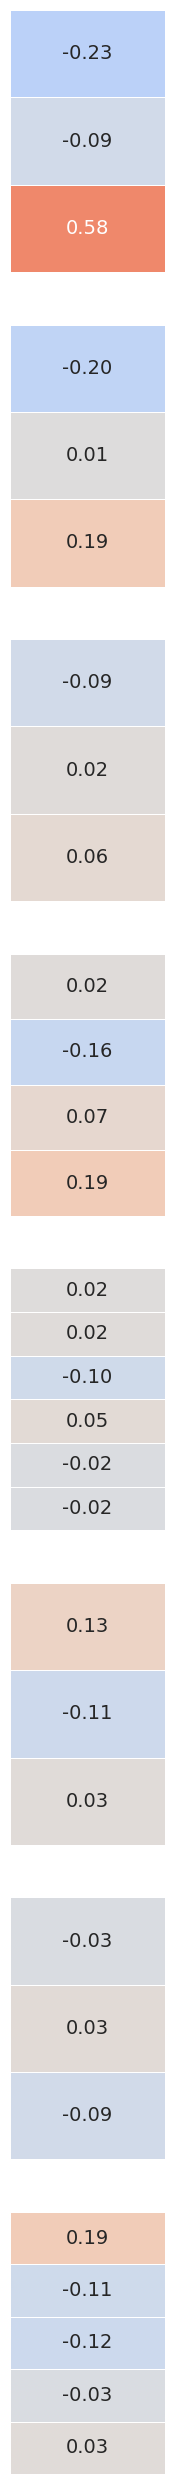

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import label
import matplotlib.gridspec as gridspec

def extract_connected_components(matrix):
    labeled_matrix, num_components = label(matrix != 0)
    components = []
    for label_id in range(1, num_components + 1):
        component_mask = labeled_matrix == label_id
        component_matrix = matrix * component_mask
        component_matrix = component_matrix[component_matrix != 0]
        components.append(component_matrix)
    return components

# Example DataFrame
trans = param_transmat
trans = trans.drop(index=['DG', 'LHb', "OPC"], columns=['DG', 'LHb', "OPC"])

components = extract_connected_components(trans.to_numpy())

# Only diagonal column, make it wider
fig = plt.figure(figsize=(2, 4 * len(components)))
gs = gridspec.GridSpec(len(components), 1)  # one column only

plt.rcParams.update({'font.size': 17})

s = 0
for index, component in enumerate(components):
    if len(component) == 1:
        continue

    size = int(np.sqrt(len(component)))
    reshaped_component = component[:size*size].reshape((size, size))

    # diagonal values only
    diag_vals = np.diag(reshaped_component).reshape(-1, 1)

    ax_diag = plt.subplot(gs[index, 0])
    sns.heatmap(
        diag_vals, annot=True, fmt=".2f",
        cmap='coolwarm', cbar=False, ax=ax_diag,
        linewidths=0.5, vmin=-1, vmax=1,
        yticklabels=False, xticklabels=False,
        annot_kws={"size": 14}
    )

    # remove all ticks and spines
    ax_diag.tick_params(left=False, bottom=False)
    for spine in ax_diag.spines.values():
        spine.set_visible(False)

    s += size

plt.savefig('param_transmat_diagonals.png', dpi=800, bbox_inches='tight')
plt.show()


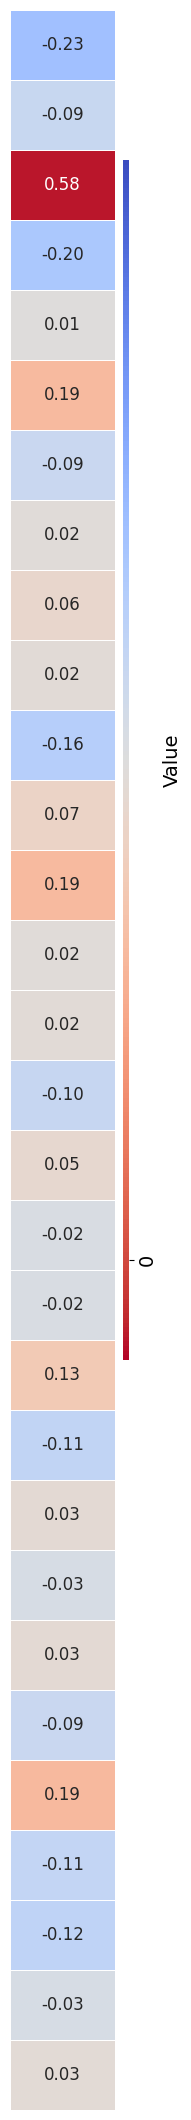

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import label

def extract_connected_components(matrix):
    labeled_matrix, num_components = label(matrix != 0)
    components = []
    for label_id in range(1, num_components + 1):
        component_mask = labeled_matrix == label_id
        component_matrix = matrix * component_mask
        component_matrix = component_matrix[component_matrix != 0]
        components.append(component_matrix)
    return components

# Example DataFrame
trans = param_transmat
trans = trans.drop(index=['DG', 'LHb', "OPC"], columns=['DG', 'LHb', "OPC"])

components = extract_connected_components(trans.to_numpy())

plt.rcParams.update({'font.size': 14})

# figure height proportional to total diagonals
n_plots = sum(int(np.sqrt(len(c))) for c in components if len(c) > 1)
fig = plt.figure(figsize=(1.5, 0.5 * n_plots))  # width narrow, height scales

current_y = 1.0
total_height = n_plots/1.4

# plot each diagonal heatmap stacked with no gaps
for component in components:
    if len(component) == 1:
        continue

    size = int(np.sqrt(len(component)))
    diag_vals = np.diag(component[:size*size].reshape((size, size))).reshape(-1, 1)

    # normalized height fraction
    h = size / total_height
    ax = fig.add_axes([0.1, current_y - h, 0.7, h])  # [left, bottom, width, height]

    sns.heatmap(
        diag_vals, annot=True, fmt=".2f",
        cmap='coolwarm', cbar=False, ax=ax,
        linewidths=0.5, vmin=-0.6, vmax=0.6,
        yticklabels=False, xticklabels=False,
        annot_kws={"size": 12}
    )

    ax.tick_params(left=False, bottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    current_y -= h

# single shared colorbar
cbar_ax = fig.add_axes([0.85, 0.1, 0.04, 0.8])
sns.heatmap(np.array([[0]]), cmap='coolwarm', vmin=-0.6, vmax=0.6,
            cbar_ax=cbar_ax, cbar=True)
cbar_ax.set_ylabel("Value")

plt.savefig("stability_diag_column.png", dpi=800, bbox_inches="tight")
plt.show()


In [ ]:
trans = param_transmat

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 2 with shape (5,) and arg 3 with shape (33,).

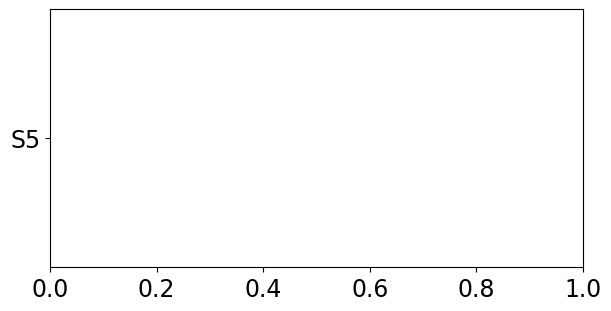

In [ ]:
import matplotlib.pyplot as plt

# Define improved figure aesthetics
fig, ax = plt.subplots(figsize=(6, len(stability) * 0.6), constrained_layout=True)

# Plot bars with better spacing and aesthetics
ax.barh(trans.index[::-1], stability[::-1], color='lightblue', edgecolor='black', height=0.6)

# Set limits and grid for better readability
ax.set_xlim(-0.5, 0.5)
ax.set_xticks([-0.5, 0, 0.5])  # Display tick marks from -1 to 1
ax.set_xticklabels(["-0.5", "0", "0.5"], fontsize=10)  # Ensure labels are visible
ax.set_yticklabels(trans.index[::-1], fontsize=12)  # Ensure correct order with clear labels
ax.set_yticks(range(len(trans.index)))  # Align y-ticks properly

# Add vertical grid lines for reference
ax.axvline(0, color='black', linewidth=1)  # Center line for balance reference

# Make bottom spine visible for tick marks
ax.spines['bottom'].set_visible(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.show()


/tmp/ipython-input-246514149.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_edge = cm.get_cmap("Reds")


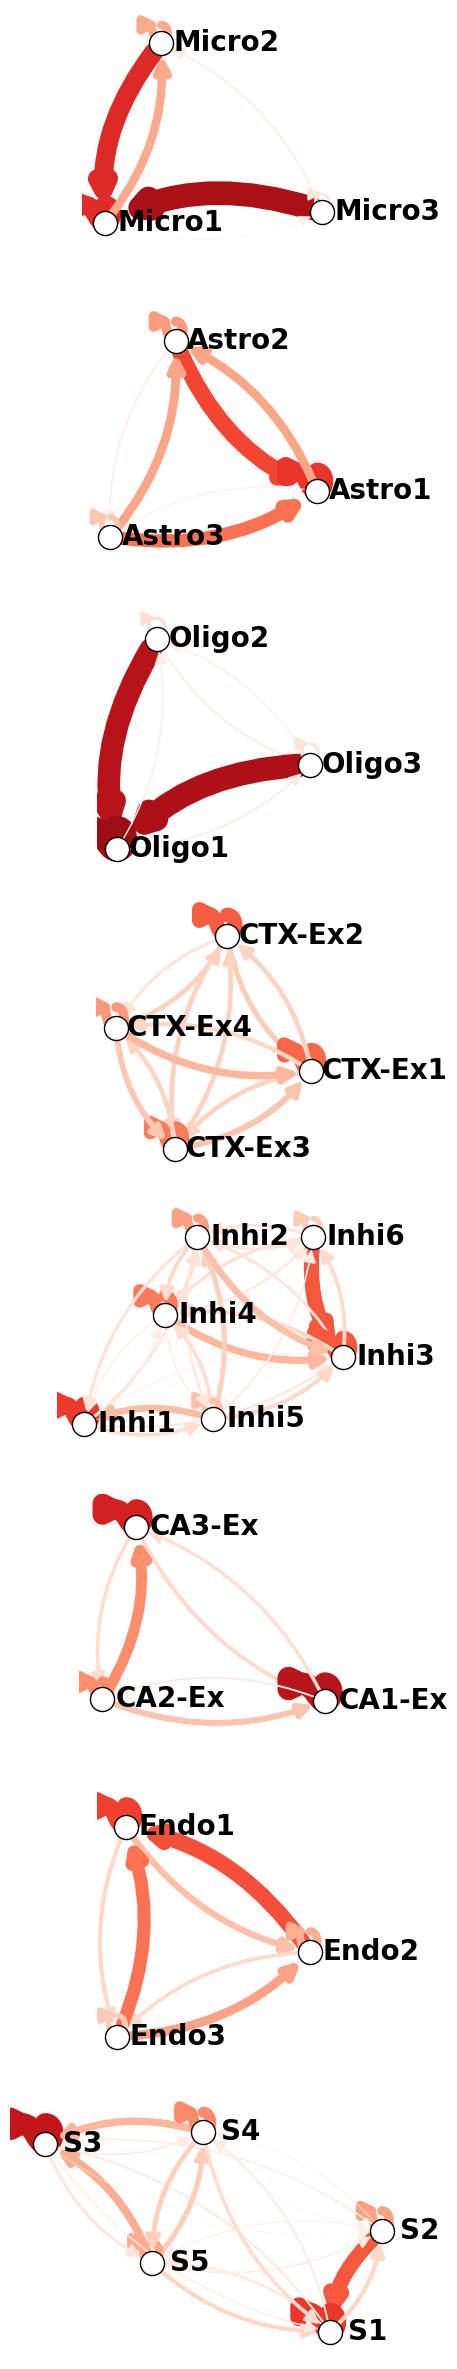

In [ ]:
trans = con_transmat_param
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# Create graph
G = nx.DiGraph()

# Add nodes
for node in trans.index:
    G.add_node(node)

# Normalize weights for colormap (bwr for edge weights)
norm_edge = mcolors.Normalize(vmin=0, vmax=1)
cmap_edge = cm.get_cmap("Reds")

# Normalize stability scores for colormap (Reds for stability scores)
# Colorbar for stability scores (Reds colormap)
colors = [(1, 1, 1), (0.5, 0.5, 0.5)]  # White to middle gray
n_bins = 100  # Number of bins to divide the colormap into
cmap_stability = mcolors.LinearSegmentedColormap.from_list("WhiteToGray", colors, N=n_bins)

# Normalize stability scores for colormap
norm_stability = mcolors.Normalize(vmin=0, vmax=1)  # Stability scores between 0 and 1

# Use the custom colormap
sm_stability = cm.ScalarMappable(cmap=cmap_stability, norm=norm_stability)
sm_stability.set_array([])  # Empty array just for colorbar
cmap_stability = sm_stability.get_cmap()

# Add edges with weights, including self-loops
edges, colors, widths = [], [], []
for i, row in trans.iterrows():
    for j, weight in row.items():
        if weight != 0:  # Include all connections, even self-loops
            G.add_edge(i, j, weight=weight)
            edges.append((i, j))
            colors.append(cmap_edge(norm_edge(weight)))  # Map color from colormap
            widths.append(abs(weight) * 10)  # Scale width

# Find connected components (subgraphs)
subgraphs = [sg for sg in nx.weakly_connected_components(G) if len(sg) > 1]
num_subgraphs = len(subgraphs)

# Define subplot grid as a vertical column
fig, axes = plt.subplots(len(subgraphs), 1, figsize=(6, 3 * len(subgraphs)))  # Width x height
if len(subgraphs) == 1:
    axes = [axes]  # Ensure axes is iterable

# Plot each subgraph in its own row
for i, subgraph_nodes in enumerate(subgraphs):
    ax = axes[i]
    subG = G.subgraph(subgraph_nodes)
    pos = nx.spring_layout(subG, seed=42)

    # # Compute stability scores
    # stability_scores = {}
    # max_stability = 0
    # for node in subG.nodes():
    #     in_edges = sum(abs(subG[u][node]["weight"]) for u in subG.predecessors(node))
    #     out_edges = sum(abs(subG[node][v]["weight"]) for v in subG.successors(node))
    #     stability_scores[node] = in_edges - out_edges
    #     max_stability = max(max_stability, stability_scores[node])

    # Normalize stability scores
    # stability_scores_norm = {
    #     node: score / max_stability if max_stability != 0 else 0
    #     for node, score in stability_scores.items()
    # }

    # Prepare edge visuals
    sub_edges = list(subG.edges())
    sub_colors = [cmap_edge(norm_edge(G[u][v]['weight'])) for u, v in sub_edges]
    sub_widths = [abs(G[u][v]['weight']) * 20 for u, v in sub_edges]

    # Draw
    #node_colors = [cmap_stability(stability_scores_norm[node]) for node in subG.nodes()]
    nx.draw_networkx_nodes(subG, pos, node_size=300, node_color='white', edgecolors="black", ax=ax)
    nx.draw_networkx_edges(subG, pos, edgelist=sub_edges, edge_color=sub_colors, width=sub_widths,
                           connectionstyle="arc3,rad=0.2", arrowsize=20, ax=ax)
    label_offset = 0.1  # adjust spacing as needed
    for node, (x, y) in pos.items():
        ax.text(
            x + label_offset, y,
            node,
            fontsize=20,
            fontweight='bold',
            verticalalignment='center',
            horizontalalignment='left',
            clip_on=False  # prevents text from being cut off
        )
    ax.set_aspect('equal')  # Force square aspect
    ax.axis("off")

# Adjust layout
plt.tight_layout()
plt.savefig("directed_graph_transitions_CON.png", bbox_inches="tight", dpi=600)
plt.show()




/tmp/ipython-input-39-1843375404.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


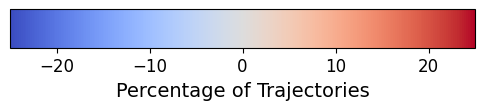

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# Set up colormap and normalization
cmap = cm.get_cmap('coolwarm')
norm = mcolors.Normalize(vmin=-25, vmax=25)

# Create the colorbar
fig, ax = plt.subplots(figsize=(6, 0.5))  # Tall, narrow figure

# Create ScalarMappable and draw colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Dummy array for colorbar

cbar = plt.colorbar(sm, cax=ax, orientation = 'horizontal')

# Configure ticks and labels
cbar.set_label("Percentage of Trajectories", fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.savefig("traj_colorbar.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import numpy as np
import pandas as pd

def compute_stability(matrix: pd.DataFrame) -> pd.Series:
    """Compute stability: diag - (sum of row excluding diag)."""
    stability = {}
    for cell_type in matrix.index:
        self_loop = matrix.at[cell_type, cell_type]
        outgoing_sum = matrix.loc[cell_type].sum() - self_loop
        stability[cell_type] = self_loop - outgoing_sum
    return pd.Series(stability)

# Drop same set of unused cell types
drop_cells = ['DG', 'LHb', 'OPC']
dis = dis_transmat_param.drop(index=drop_cells, columns=drop_cells)
con = con_transmat_param.drop(index=drop_cells, columns=drop_cells)

# Compute stabilities
dis_stability = compute_stability(dis)
con_stability = compute_stability(con)

# Calculate differential stabilities (DIS - CON)
differential_stability = dis_stability - con_stability

In [ ]:
order

,0
0,Micro1
1,Micro2
2,Micro3
3,Astro1
4,Astro2
5,Astro3
6,Oligo1
7,Oligo2
8,Oligo3
9,OPC


In [ ]:
import numpy as np
import pandas as pd

def compute_stability(matrix: pd.DataFrame) -> pd.Series:
    """Compute stability: diag - (sum of row excluding diag)."""
    stability = {}
    for cell_type in matrix.index:
        stability[cell_type] = matrix.at[cell_type, cell_type]
    return pd.Series(stability)

# Drop same set of unused cell types
drop_cells = ['DG', 'LHb', 'OPC']
dis = dis_transmat_param.drop(index=drop_cells, columns=drop_cells)
con = con_transmat_param.drop(index=drop_cells, columns=drop_cells)

# Compute stabilities
dis_stability = compute_stability(dis)
con_stability = compute_stability(con)

# Calculate differential stabilities (DIS - CON)
differential_stability = dis_stability - con_stability

/tmp/ipython-input-1841781466.py:21: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


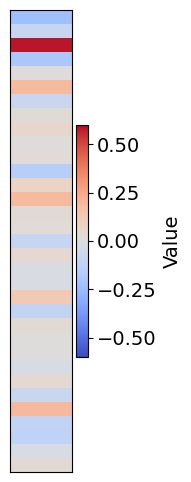

In [ ]:
# order = order.replace(inhi_mapping)
# order = order.squeeze()   # Series if 1-col DataFrame
# order = order.tolist()    # plain list
differential_stability_copy = np.array(differential_stability.reindex(order, fill_value=0))

# reshape into vertical column
data = differential_stability_copy.reshape(-1, 1)

# Plot
fig, ax = plt.subplots(figsize=(1, 6))  # narrow and tall
im = ax.imshow(data, cmap='coolwarm', aspect='auto', vmin=-0.6, vmax=0.6)

# Remove ticks
ax.set_xticks([])
ax.set_yticks([])

# Add colorbar
cbar = plt.colorbar(im, ax=ax, orientation='vertical')
cbar.set_label("Value")

plt.tight_layout()
plt.savefig("1d_vertical_diag_heatmap.png", dpi=600, bbox_inches='tight')
plt.show()


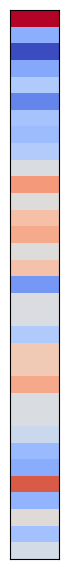

In [ ]:
order = order.replace(inhi_mapping)
order = order.squeeze()  # converts 1-column DataFrame to Series if needed
order = order.tolist()   # ensure it's a plain list
differential_stability_copy = differential_stability.reindex(order, fill_value=0)


data = np.array(differential_stability_copy).reshape(-1, 1)
# Plot
fig, ax = plt.subplots(figsize=(1, 6))  # tall and narrow
im = ax.imshow(data, cmap='coolwarm', aspect='auto')

# Remove ticks
ax.set_xticks([])
ax.set_yticks([])

# Optional: add colorbar
#plt.colorbar(im, ax=ax, orientation='vertical')

plt.tight_layout()
plt.savefig("1d_vertical_heatmap.png", dpi=600, bbox_inches='tight')
plt.show()

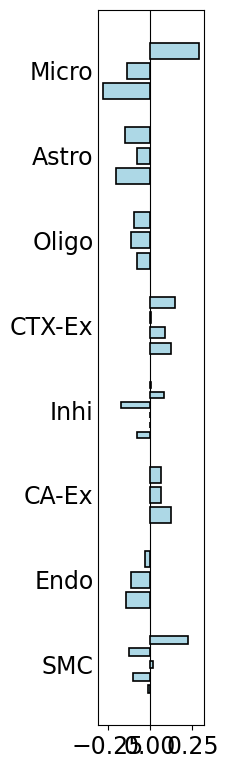

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define ordered groups
cell_types_ordered = {
    "Micro": ["Micro1", "Micro2", "Micro3"],
    "Astro": ["Astro1", "Astro2", "Astro3"],
    "Oligo": ["Oligo1", "Oligo2", "Oligo3"],
    "CTX-Ex": ["CTX-Ex1", "CTX-Ex2", "CTX-Ex3", "CTX-Ex4"],
    "Inhi": ["Inhi1", "Inhi2", "Inhi3", "Inhi4", "Inhi5", "Inhi6"],
    "CA-Ex": ["CA1-Ex", "CA2-Ex", "CA3-Ex"],
    "Endo": ["Endo1", "Endo2", "Endo3"],
    "SMC": ["S1", "S2", "S3", "S4", "S5"]
}

keys = list(cell_types_ordered.keys())
num_groups = len(keys)

group_height = 1.0        # Total vertical space per group
gap_size_group = 0.5      # Gap between groups
gap_size_bar = 0.075      # Gap between individual bars within a group

y_positions = []
bar_heights = []
group_centers = []

current_y = 0
for key in keys:
    states = cell_types_ordered[key]
    n_states = len(states)

    # Total space for gaps + bars
    total_bar_gap_space = gap_size_bar * (n_states - 1)
    available_space = group_height - total_bar_gap_space
    bar_height = available_space / n_states

    for i in range(n_states):
        y_center = current_y + i * (bar_height + gap_size_bar) + bar_height / 2
        y_positions.append(y_center)
        bar_heights.append(bar_height)

    group_center = current_y + (n_states * (bar_height + gap_size_bar) - gap_size_bar) / 2
    group_centers.append(group_center)

    current_y += group_height + gap_size_group

# Convert to arrays
y_positions = np.array(y_positions)
bar_heights = np.array(bar_heights)
diff_stability_arr = np.array(differential_stability)

# Plot
fig, ax = plt.subplots(figsize=(2.5, 8))
ax.barh(
    y_positions,
    diff_stability_arr,
    height=bar_heights,
    color='lightblue',
    edgecolor='black',
    linewidth=1.2,
    zorder=3
)

# Zero line
ax.axvline(0, color='black', linewidth=0.8, zorder=1)

# Group labels
ax.set_yticks(group_centers)
ax.set_yticklabels(keys)

# Invert y-axis so first group is on top
ax.invert_yaxis()

# Clean up tick lines
ax.tick_params(axis='y', which='both', length=0)

plt.tight_layout()
plt.savefig('barplot.png', dpi=600, bbox_inches='tight')
plt.show()

# Gene interpolation

In [ ]:
import pandas as pd
import os
os.chdir('/content/drive/MyDrive/mAD Dataset')

In [ ]:
all_cells = pd.read_csv(r"nonpert_cells_interpolate_DISEASE_5-11-25.csv")
all_gene_list = pd.read_csv(r"nonpert_gene_list_DISEASE_interpolate_5-11-25.csv")

In [ ]:
all_cells = pd.DataFrame(all_cells)

In [ ]:
maps = pd.read_csv("maps_cleaned.csv")

In [ ]:
maps_c = pd.read_csv('maps_cleaned_CONTROL.csv')

In [ ]:
all_gene_list_c = pd.read_csv("nonpert_gene_list_CONTROL_interpolate_5-19-25.csv")

In [ ]:
#maps.to_csv("maps.csv")

In [ ]:
maps = maps.drop("Unnamed: 0", axis = 1)
maps = maps.drop("Unnamed: 0.1", axis = 1)

In [ ]:
maps_c = maps_c.drop("Unnamed: 0", axis = 1)
maps_c = maps_c.drop("Unnamed: 0.1", axis = 1)

In [ ]:
# all_cells.iloc[0] = metad[metad['timepoint']==0].iloc[maps['8'].astype(int)]['cell_type']
# all_cells.iloc[20] = metad[metad['timepoint']==1].iloc[maps['13'].astype(int)]['cell_type']

In [ ]:
weights = list(maps['weights'])

In [ ]:
weights_c = list(maps_c['weights'])

In [ ]:
legend = {'Astro1': '#8c564b',
 'Astro2': '#8c564b',
 'Astro3': '#8c564b',
 'CA1-Ex': '#ffbb78',
 'CA2-Ex': '#98df8a',
 'CA3-Ex': '#d62728',
 'Micro1': '#f7b6d2',
 'Micro2': '#f7b6d2',
 'Micro3': '#f7b6d2',
 'CTX-Ex1': '#1f77b4',
 'CTX-Ex2': '#1f77b4',
 'CTX-Ex3': '#1f77b4',
 'CTX-Ex4': '#1f77b4',
 'DG': '#9467bd',
 'Endo1': '#c49c94',
 'Endo2': '#c49c94',
 'Endo3': '#c49c94',
 'LHb': '#b9f635',
 'Lamp5': '#aec7e8',
 'Pvalb': '#aec7e8',
 'Pvalb_Nog': '#aec7e8',
 'S1': '#17becf',
 'S2': '#17becf',
 'S3': '#17becf',
 'S4': '#17becf',
 'S5': '#17becf',
 'Cnr1': '#aec7e8',
 'OPC': '#9edae5',
 'Oligo1': '#c7c7c7',
 'Oligo2': '#c7c7c7',
 'Oligo3': '#c7c7c7',
 'Sst': '#aec7e8',
 'Vip': '#aec7e8'}
cell_types = ['Micro1',
 'Micro2',
 'Micro3',
 'Astro1',
 'Astro2',
 'Astro3',
 'Oligo1',
 'Oligo2',
 'Oligo3',
 'OPC',
 'CTX-Ex1',
 'CTX-Ex2',
 'CTX-Ex3',
 'CTX-Ex4',
 'Cnr1',
 'Lamp5',
 'Pvalb',
 'Sst',
 'Vip',
 'Pvalb_Nog',
 'CA1-Ex',
 'CA2-Ex',
 'CA3-Ex',
 'DG',
 'LHb',
 'Endo1',
 'Endo2',
 'Endo3',
 'S1',
 'S2',
 'S3',
 'S4',
 'S5']


In [ ]:
maps

,8,13,weights,cell_type
0,5404,2,0.000011,Astro
1,14017,3,0.000008,CTX-Ex
2,14450,5,0.000028,CTX-Ex
3,5408,6,0.000004,Oligo
4,8645,7,0.000004,Micro
...,...,...,...,...
88790,16382,9266,0.000002,SMC
88791,16383,16566,0.000002,SMC
88792,16384,18871,0.000003,SMC
88793,16385,12848,0.000005,SMC


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats

def weighted_avg_segments(df, weights_in, segments, ctype):
    gene_cols = df.columns[3:]
    timepoints = sorted(df['timepoint'].unique())
    results = [[] for _ in segments]
    weights_filtered = weights_in[maps['cell_states'] == ctype]

    for tp in timepoints:
        subset = df[df['timepoint'] == tp].reset_index(drop=True)
        subset = subset[maps['cell_states'] == ctype]
        for i, (start, end) in enumerate(segments):
            segment_cols = gene_cols[start:end]
            data = subset[segment_cols]
            weighted = data.mul(weights_filtered, axis=0) / sum(weights_filtered)
            results[i].append(weighted.mean(axis=1).mean())

    return timepoints, results

# Define segments
segments = [
    (0, 16),    # Plaque, UP
    (16, 31),   # Tau, UP
    (31, 46),   # Plaque, DOWN
    (46, 60)    # Tau, DOWN
]

gene_set_labels = ["Plaque, UP", "Tau, UP", "Plaque, DOWN", "Tau, DOWN"]


# Collect data for each remaining cell type
all_rows = []
for ctype in cell_types:
    tp_all, results_all = weighted_avg_segments(all_gene_list, weights, segments, ctype)
    all_rows.append(results_all)

# Update num_cell_types accordingly
all_rows = np.array(all_rows)  # shape: (num_cell_types, 4, num_timepoints)
num_cell_types = len(cell_types)

In [ ]:
tp_all = [n for n in range(0,21)]

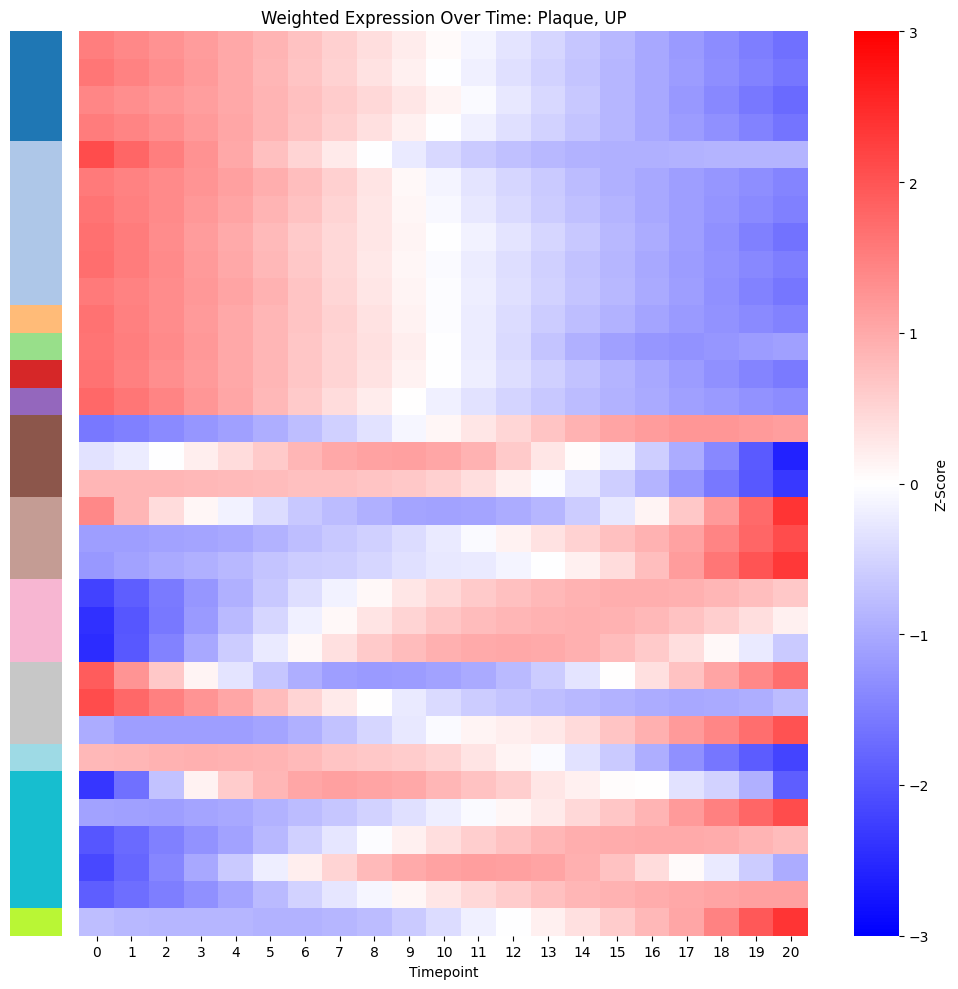

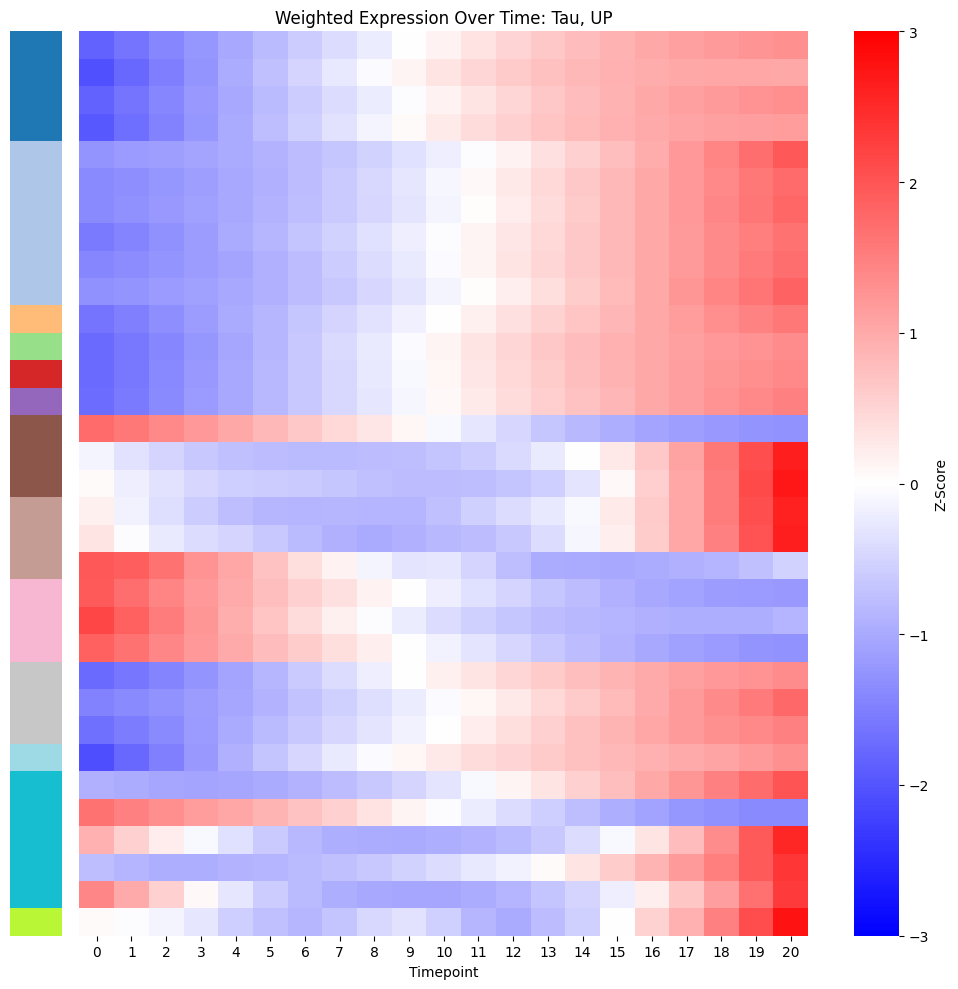

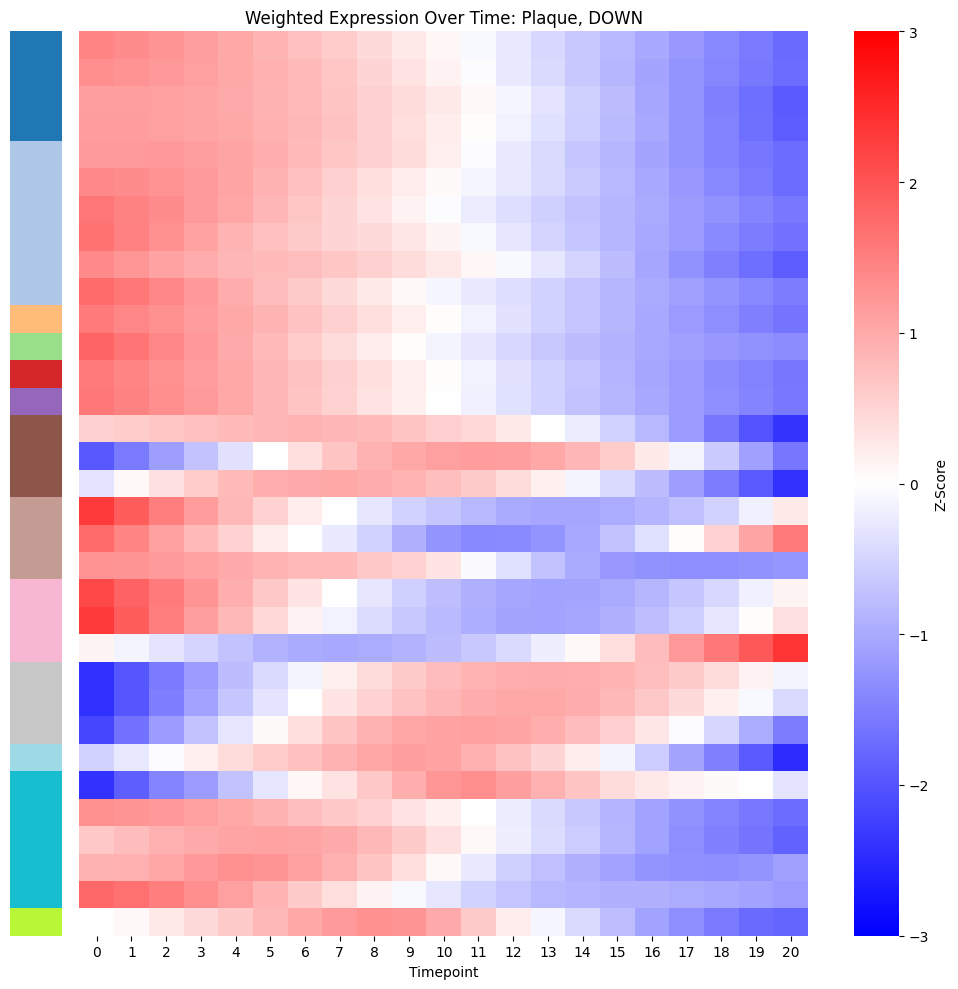

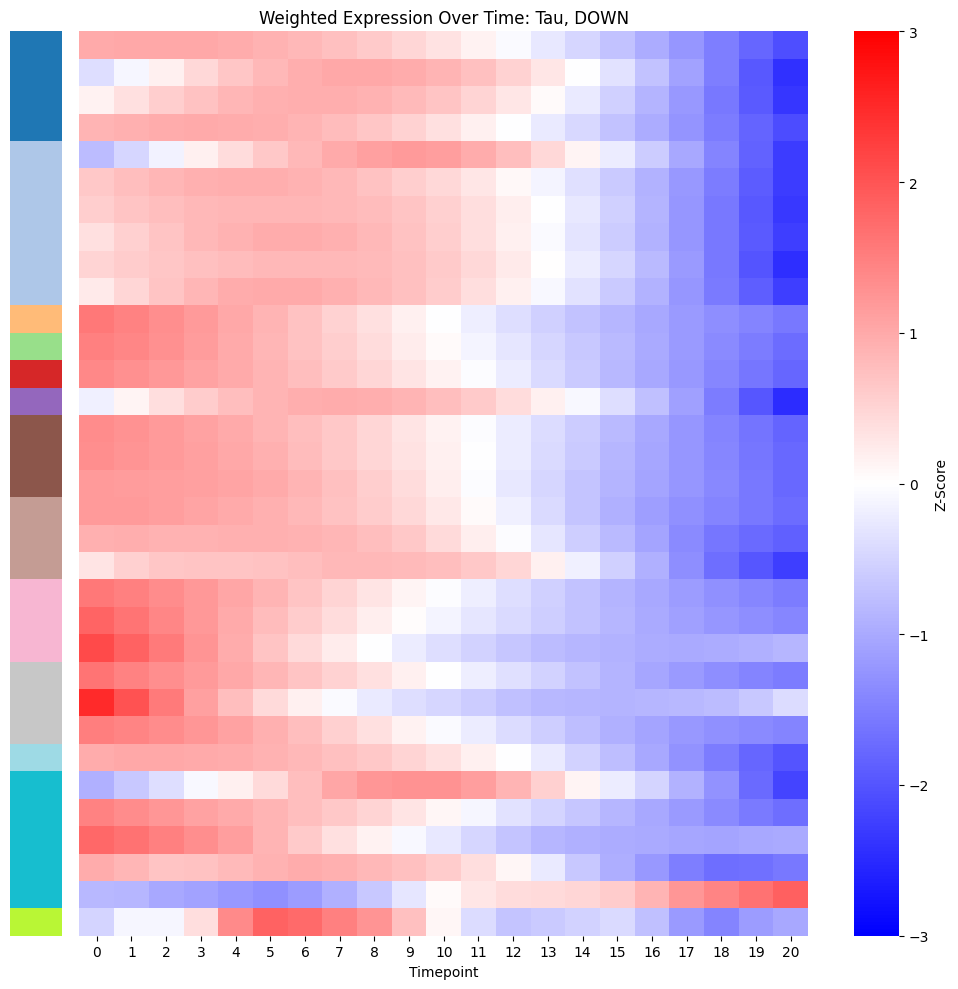

In [ ]:
for i, gene_set in enumerate(gene_set_labels):
    # Extract expression per cell type for this gene set
    raw_data = [all_rows[ct_idx][i] for ct_idx in range(num_cell_types)]

    # Compute z-scores
    z_data = [scipy.stats.zscore(row) for row in raw_data]

    # Compute scaling factors
    row_means = [np.mean(row) for row in raw_data]
    max_mean = max(row_means)
    scale_factors = [mean / max_mean if max_mean != 0 else 0 for mean in row_means]

    # Apply scaling to z-scores
    scaled_z_data = [z * abs(scale) for z, scale in zip(z_data, scale_factors)]

    # Build dataframe and plot
    df = pd.DataFrame(z_data, index=cell_types, columns=tp_all)

    plt.figure(figsize=(10, 10))
    ax = sns.heatmap(df, cmap="bwr", cbar=True, xticklabels=True, yticklabels=False, vmin=-3, vmax=3)
    ax.figure.axes[-1].set_ylabel("Z-Score", fontsize=10)
    plt.xlabel("Timepoint")
    plt.title(f"Weighted Expression Over Time: {gene_set}")

    # Draw colored boxes as y-axis labels
    n_cells = len(cell_types)
    for j, ct in enumerate(df.index):
        color = legend.get(ct, '#000000')  # fallback to black if not in legend
        ax.add_patch(plt.Rectangle(
            (-0.5 - 1.5, j),  # x, y
            1.5, 1,           # width, height
            facecolor=color,
            edgecolor='none',
            clip_on=False,
            transform=ax.transData,
            zorder=10
        ))

    plt.tight_layout()
    #plt.savefig(f'Expression_Ctypes_{gene_set}.png', dpi=600, bbox_inches='tight')
    plt.show()

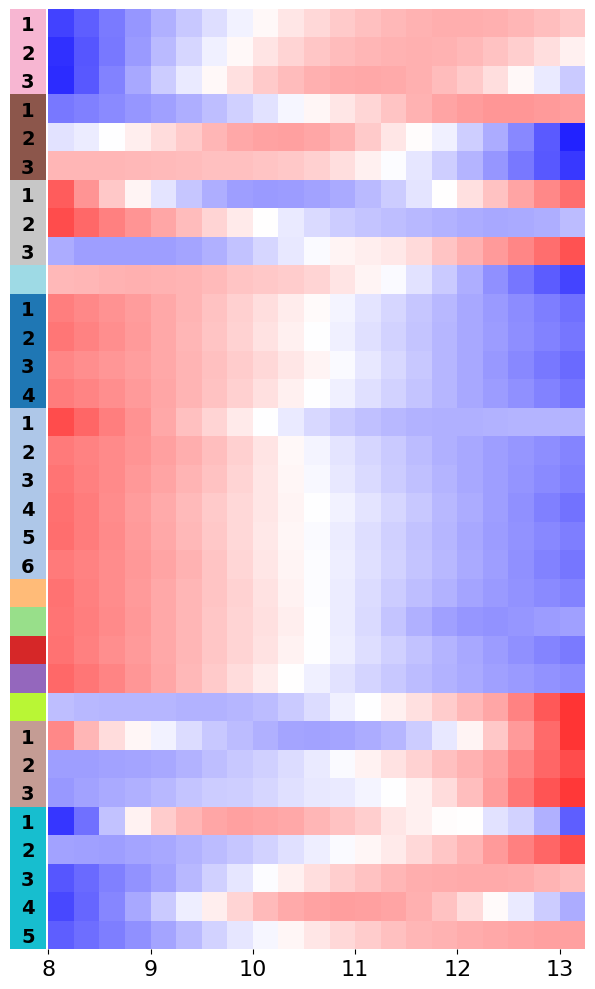

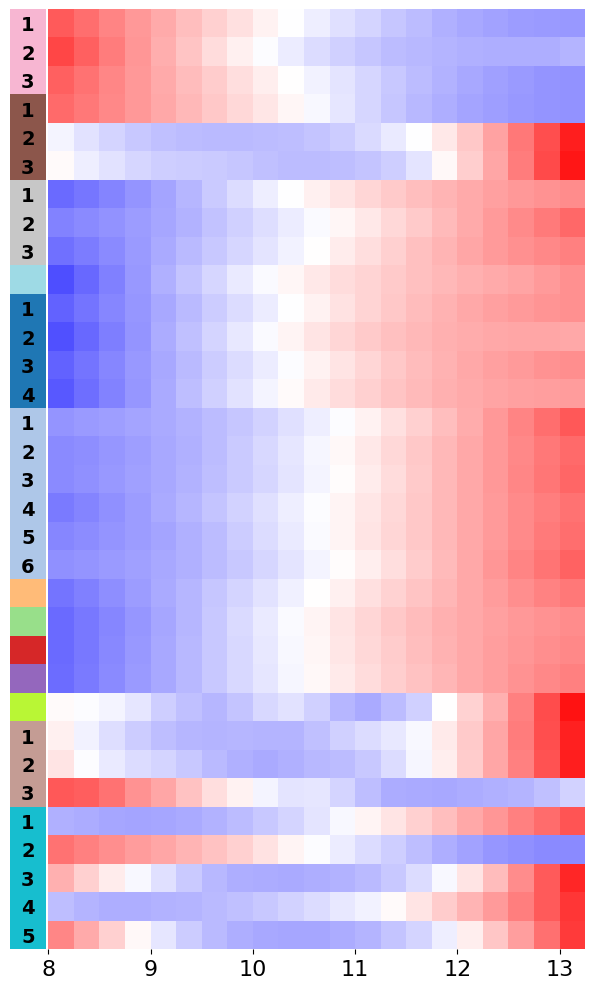

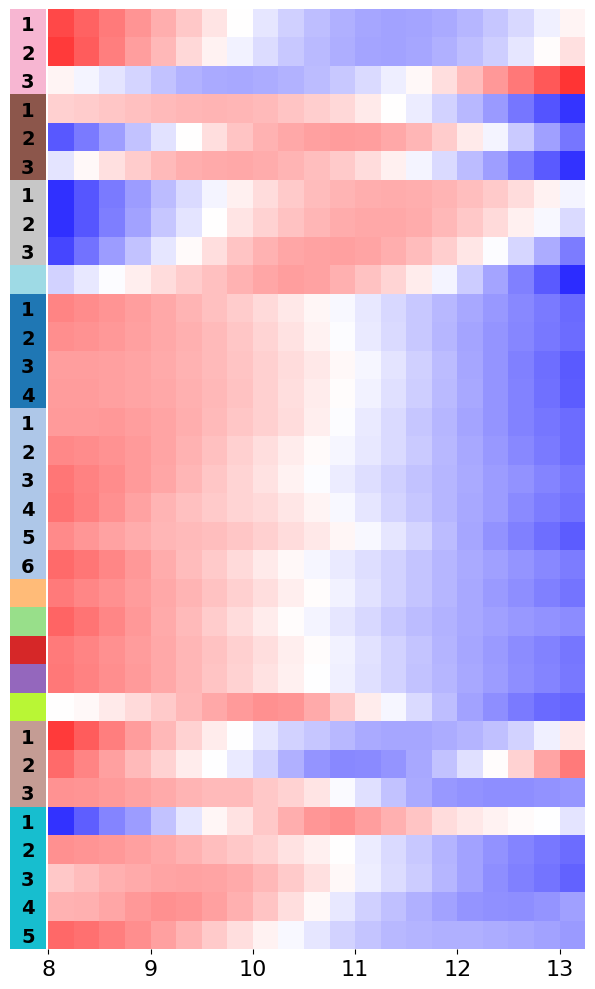

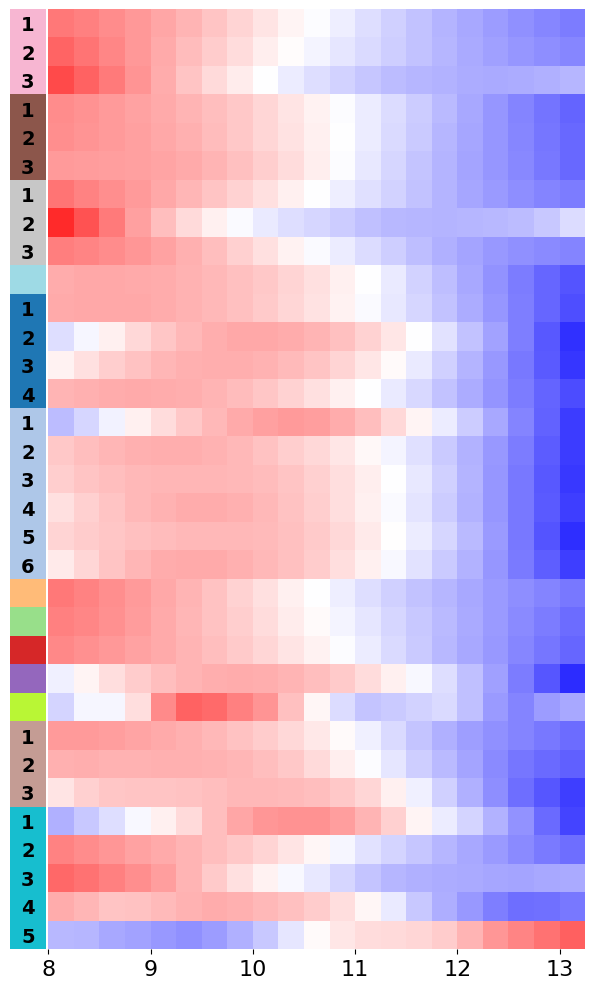

In [ ]:
from scipy.cluster.hierarchy import linkage, leaves_list
import matplotlib.patches as patches


# Manual overrides
manual_map = {
    'Cnr1': '1',
    'Lamp5': '2',
    'Pvalb': '3',
    'Sst': '4',
    'Vip': '5',
    'Pvalb_Nog': '6'
}

for i, gene_set in enumerate(gene_set_labels):
    # Extract expression per cell type for this gene set
    raw_data = [all_rows[ct_idx][i] for ct_idx in range(num_cell_types)]

    # Compute z-scores
    z_data = [scipy.stats.zscore(row) for row in raw_data]

    # Compute scaling factors
    row_means = [np.mean(row) for row in raw_data]
    max_mean = max(row_means)
    scale_factors = [mean / max_mean if max_mean != 0 else 0 for mean in row_means]

    # Apply scaling to z-scores
    scaled_z_data = [z * abs(scale) for z, scale in zip(z_data, scale_factors)]

    # Build dataframe
    df = pd.DataFrame(z_data, index=cell_types, columns=tp_all)

    # Center of mass calculation
    # com = df.apply(lambda row: np.average(tp_all, weights=(row + 5)), axis=1)
    # df_sorted = df.loc[com.sort_values(ascending=False).index]

    # Plot
    plt.figure(figsize=(6, 10))
    ax = sns.heatmap(df, cmap="bwr", cbar=False, xticklabels=False, yticklabels=False, vmin=-3, vmax=3)
    ax.figure.axes[-1].set_ylabel("Z-Score", fontsize=10)
    plt.xlabel("Timepoint")
    plt.title(f"Weighted Expression Over Time: {gene_set}")

    # Draw color boxes as y-axis labels, and add number text if applicable
    for y, ct in enumerate(df.index):
        color = legend.get(ct, '#000000')  # fallback to black if missing
        ax.add_patch(patches.Rectangle(
            (-1.5, y),   # x, y
            1.4, 1,        # width, height
            linewidth=0,
            edgecolor=None,
            facecolor=color,
            clip_on=False,
            transform=ax.transData
        ))

        # Determine number to display (manual override or numeric suffix)
        if ct in manual_map:
            number = manual_map[ct]
        else:
            number = ct[-1] if ct[-1].isdigit() else None

        if number:
            ax.text(-0.8, y + 0.55, number,
                    va='center', ha='center', fontsize=14, color='black', weight='bold',
                    transform=ax.transData, zorder=11)
        # Custom x-axis: ticks from 8 to 13, evenly mapped to timepoints
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    ax.tick_params(left=False, bottom=True, labelbottom=True)

    num_timepoints = df.shape[1]
    new_xtick_labels = list(range(8, 14))  # 8 to 13
    xtick_positions = np.linspace(0, num_timepoints - 1, len(new_xtick_labels))

    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(new_xtick_labels, fontsize=16)

    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.tight_layout()
    plt.savefig(f'Expression_Ctypes_NewOrder_{gene_set}.png', dpi=600, bbox_inches='tight', pad_inches = 0)
    plt.show()


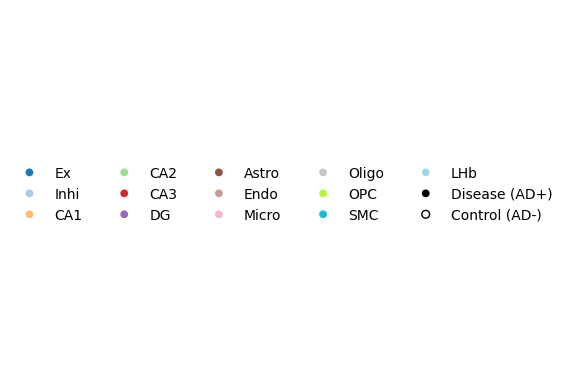

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerPatch
import matplotlib.patches as mpatches

# Define category colors
category_colors = {
    "Ex": "#1f77b4",
    "Inhi": "#aec7e8",
    "CA1": "#ffbb78",
    "CA2": "#98df8a",
    "CA3": "#d62728",
    "DG": "#9467bd",
    "Astro": "#8c564b",
    "Endo": "#c49c94",
    "Micro": "#f7b6d2",
    "Oligo": "#c7c7c7",
    "OPC": "#b9f635",
    "SMC": "#17becf",
    "LHb": "#9edae5",
    "Disease (AD+)": "black",
    "Control (AD-)": "white"
}

# Custom handler to make legend markers circular
class HandlerCircle(HandlerPatch):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        center = 0.5 * width - xdescent, 0.5 * height - ydescent
        p = mpatches.Circle(xy=center, radius=min(width, height)/2.5)
        self.update_prop(p, orig_handle, legend)
        p.set_transform(trans)
        return [p]

# Create legend elements (circle patches)
legend_elements = [
    mpatches.Circle((0, 0), radius=5, facecolor=color, edgecolor='black' if color == 'white' else 'none', label=label)
    for label, color in category_colors.items()
]

# Plot dummy figure and add legend
fig, ax = plt.subplots()
ax.axis('off')

# Create the legend with multiple columns (5 per row)
legend = ax.legend(
    handles=legend_elements,
    loc='center',
    ncol=5,
    frameon=False,
    handler_map={mpatches.Circle: HandlerCircle()},
    borderaxespad=0.5,
    fontsize=10
)
plt.savefig('legend_ctypes.png', dpi= 800, bbox_inches = 'tight')
plt.show()


# PERTURB sc4D

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.chdir('/content/drive/MyDrive/mAD Dataset')

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import backend as K
import keras

@keras.saving.register_keras_serializable()
def zero_inflated_mse(y_true, y_pred):

    # Separate data into zeros and non-zeros
    zeros_mask = tf.equal(y_true, 0)
    non_zeros_mask = ~zeros_mask

    # Calculate mean squared error for non-zeros
    mse_non_zeros = K.mean(K.square(tf.boolean_mask(y_true, non_zeros_mask) - tf.boolean_mask(y_pred, non_zeros_mask)))

    # Calculate mean squared error for zeros
    mse_zeros = K.mean(K.square(tf.boolean_mask(y_true, zeros_mask) - tf.boolean_mask(y_pred, zeros_mask)))
    return (mse_zeros + mse_non_zeros)/2
# Replace 'your_model_file_path' with the actual path to your .keras file
autoencoder = tf.keras.models.load_model(
    'autoencoder_v9.keras',
    custom_objects={'zero_inflated_mse': zero_inflated_mse}
)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 34 variables whereas the saved optimizer has 33 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
trained_decoder = autoencoder.layers[1]
trained_encoder = autoencoder.layers[0]

In [ ]:
sig_genes_t = pd.read_csv("/content/drive/MyDrive/mAD Dataset/all_genes_tau.csv")
sig_genes_p = pd.read_csv("/content/drive/MyDrive/mAD Dataset/all_genes_plaque.csv")

plaque_sigs_up = list(sig_genes_p[sig_genes_p['log2FoldChange'] > 0].sort_values(by = 'pvalue')[:15]["Symbol"])
plaque_sigs_down = list(sig_genes_p[sig_genes_p['log2FoldChange'] < 0].sort_values(by = 'pvalue')[:15]["Symbol"])
tau_sigs_up = list(sig_genes_t[sig_genes_t['log2FoldChange'] > 0].sort_values(by = 'pvalue')[:15]["Unnamed: 0"])
tau_sigs_down = list(sig_genes_t[sig_genes_t['log2FoldChange'] < 0].sort_values(by = 'pvalue')[:15]["Unnamed: 0"])

plaque_sigs_up = ([x.upper() for x in plaque_sigs_up])
plaque_sigs_down = ([x.upper() for x in plaque_sigs_down])
tau_sigs_up = ([x.upper() for x in tau_sigs_up])
tau_sigs_down = ([x.upper() for x in tau_sigs_down])

In [ ]:
DONEPEZIL_SET = ['ACHE', 'BCHE', 'APOE']

In [ ]:
in_data = pd.concat([xmatd, xmatc])

In [ ]:
in_data = in_data.drop(['id', 'GENE'], axis = 1)

In [ ]:
in_meta = pd.concat([metad, metac])

In [ ]:
import sklearn
import numpy as np  # always need it
import pylab as pl  # do the plots

import ot  # ot

import time

In [ ]:
def perturb_ot(gene_set, percent):
    # Copy input data to avoid in-place mutation
    data_copy = in_data.copy()
    meta_copy = in_meta.copy()

    # Subset timepoint 0 data
    time0_mask = meta_copy['timepoint'] == 0
    gene_values = data_copy.loc[time0_mask, gene_set]

    # Apply knockdown or upregulation
    if percent < 1:
        data_copy.loc[time0_mask, gene_set] = gene_values * percent
    else:
        nonzero_mean = gene_values.mask(gene_values == 0).mean()
        replaced_values = gene_values.where(gene_values != 0, other=nonzero_mean, axis=1)
        data_copy.loc[time0_mask, gene_set] = replaced_values * percent

    # Encode latent representation
    lat = trained_encoder.predict(data_copy)
    xp = pd.DataFrame(lat)
    xs = xp.loc[:, (xp != 0).any(axis=0)]
    xs.index = list(xmatd.index) + list(xmatc.index)

    # PCA reduction
    pca = sklearn.decomposition.PCA(n_components=5)
    xp_ = pca.fit_transform(xs)
    xp = pd.DataFrame(xp_, index=xs.index)
    xpd = xp.loc[xmatd.index]

    # Split source and target
    xs = xpd[metad['timepoint'] == 0]
    xt = xpd[metad['timepoint'] == 1]

    # Compute OT
    a = np.ones(xs.shape[0]) / xs.shape[0]
    b = np.ones(xt.shape[0]) / xt.shape[0]
    M = ot.dist(np.array(xs), np.array(xt))
    M /= M.max()

    reg = 0.0005
    reg_m_kl = 0.05
    ot_matrix = ot.unbalanced.sinkhorn_unbalanced(a, b, M, reg, reg_m_kl)
    ot_df = pd.DataFrame(ot_matrix)

    # Cell mapping
    maps_8 = pd.DataFrame(ot_df.idxmax(axis=1), columns=["13"])
    maps_8["8"] = maps_8.index
    maps_13 = pd.DataFrame(ot_df.idxmax(axis=0), columns=["8"])
    maps_13["13"] = maps_13.index

    unique_values = maps_13["8"].unique()
    remaining_values = set(range(18309)) - set(unique_values)
    filtered_rows = maps_8[maps_8["8"].isin(remaining_values)]

    maps = pd.concat([maps_13, filtered_rows], ignore_index=True).drop_duplicates()
    maps['weights'] = maps.apply(lambda row: ot_df.iloc[row['8'], row['13']], axis=1)
    maps = maps[maps['weights'] != 0].reset_index(drop=True)

    # Aggregate by cell types
    values_s = metad[metad['timepoint'] == 0]['cell_type']
    values_t = metad[metad['timepoint'] == 1]['cell_type']
    transmat = ot_df.copy()
    transmat.index = values_s.iloc[ot_df.index]
    transmat.columns = values_t.iloc[ot_df.columns]

    transmat = transmat.groupby(transmat.index).sum()
    transmat = transmat.T.groupby(transmat.T.index).sum().T

    # Normalize rows to percentage
    normalized_transmat = transmat.div(transmat.sum(axis=1), axis=0) * 100
    return normalized_transmat

In [ ]:
PU_transmat = perturb_ot(plaque_sigs_up, 0.2)

2256/2256 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


In [ ]:
PU_transmat.to_csv('PU_transmat.csv')

In [ ]:
PD_transmat = perturb_ot(plaque_sigs_down, 1.8)

2256/2256 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


/usr/local/lib/python3.11/dist-packages/ot/unbalanced/_sinkhorn.py:738: RuntimeWarning: divide by zero encountered in divide
  u = (a / Kv) ** fi_1
/usr/local/lib/python3.11/dist-packages/ot/unbalanced/_sinkhorn.py:751: UserWarning: Numerical errors at iteration 0
  warnings.warn("Numerical errors at iteration %s" % i)


In [ ]:
PD_transmat.to_csv("PD_transmat.csv")

In [ ]:
TU_transmat = perturb_ot(tau_sigs_up, 0.2)

2256/2256 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


In [ ]:
TU_transmat.to_csv("TU_transmat.csv")

In [ ]:
TD_transmat = perturb_ot(tau_sigs_down, 1.8)

2256/2256 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step


/usr/local/lib/python3.11/dist-packages/ot/unbalanced/_sinkhorn.py:738: RuntimeWarning: divide by zero encountered in divide
  u = (a / Kv) ** fi_1
/usr/local/lib/python3.11/dist-packages/ot/unbalanced/_sinkhorn.py:751: UserWarning: Numerical errors at iteration 0
  warnings.warn("Numerical errors at iteration %s" % i)


In [ ]:
TD_transmat.to_csv('TD_transmat.csv')

In [ ]:
DONEPEZIL = perturb_ot(DONEPEZIL_SET, 0.2)

2256/2256 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


/usr/local/lib/python3.11/dist-packages/ot/unbalanced/_sinkhorn.py:740: RuntimeWarning: divide by zero encountered in divide
  v = (b / Ktu) ** fi_2
/usr/local/lib/python3.11/dist-packages/ot/unbalanced/_sinkhorn.py:751: UserWarning: Numerical errors at iteration 0
  warnings.warn("Numerical errors at iteration %s" % i)


In [ ]:
DONEPEZIL.to_csv('donepezil_transmat.csv')

# PLOT PERTURBATIONS

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

In [ ]:

os.chdir('/content/drive/MyDrive/mAD Dataset')

In [ ]:
PU_transmat = pd.read_csv("PU_transmat.csv", index_col = 0)
PD_transmat = pd.read_csv("PD_transmat.csv", index_col = 0)
TU_transmat = pd.read_csv("TU_transmat.csv", index_col = 0)
TD_transmat = pd.read_csv("TD_transmat.csv", index_col = 0)
DONEPEZIL = pd.read_csv("donepezil_transmat.csv", index_col = 0)
dis_transmat = pd.read_csv("transmat-disease.csv", index_col = 0)

In [ ]:

import io
import pandas as pd
order = pd.read_csv(io.StringIO('''
CTX-Ex1
CTX-Ex2
CTX-Ex3
CTX-Ex4
Cnr1
Lamp5
Pvalb
Sst
Vip
Pvalb_Nog
CA1-Ex
CA2-Ex
CA3-Ex
DG
LHb
Astro1
Astro2
Astro3
Endo1
Endo2
Endo3
Micro1
Micro2
Micro3
Oligo1
Oligo2
Oligo3
OPC
S1
S2
S3
S4
S5
'''), header=None)

In [ ]:
def reparam(transmat):
  transmat = transmat.reindex(columns=order[0])
  transmat = transmat.reindex(index = order[0])
  cell_types = {
    "CTX-Ex": ["CTX-Ex1", "CTX-Ex2", "CTX-Ex3", "CTX-Ex4"],
    "Inhi": ["Cnr1", "Lamp5", "Pvalb", "Sst", "Vip", "Pvalb_Nog"],
    "CA-Ex": ["CA1-Ex", "CA2-Ex", "CA3-Ex"],
    "DG": ["DG"],
    "Astro": ["Astro1", "Astro2", "Astro3"],
    "Endo": ["Endo1", "Endo2", "Endo3"],
    "Micro": ["Micro1", "Micro2", "Micro3"],
    "Oligo": ["Oligo1", "Oligo2", "Oligo3"],
    "SMC": ["S1", "S2", "S3", "S4", "S5"],
    "LHb": ["LHb"],
  }

  # Assuming dis_transmat is already loaded as a DataFrame
  transmat_param = pd.DataFrame(0, index=transmat.index, columns=transmat.columns)

  for top_type, subtypes in cell_types.items():
      # Extract square matrix for the current top-level cell type
      submatrix = transmat.loc[subtypes, subtypes].copy()

      # Normalize each column so that its sum is 1
      submatrix = submatrix.div(submatrix.sum(axis=1), axis=0).fillna(0)

      # Place the normalized submatrix into dis_transmat_param
      transmat_param.loc[subtypes, subtypes] = submatrix

  return transmat_param

In [ ]:
PU_param = reparam(PU_transmat)
PD_param = reparam(PD_transmat)
TU_param = reparam(TU_transmat)
TD_param = reparam(TD_transmat)
DONEPEZIL_param = reparam(DONEPEZIL)
dis_transmat_param = reparam(dis_transmat)

/tmp/ipython-input-3057433905.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.33666019 0.128428   0.25818804 0.28698974]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  transmat_param.loc[subtypes, subtypes] = submatrix
/tmp/ipython-input-3057433905.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.07321475 0.46805655 0.16142256 0.11441079]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  transmat_param.loc[subtypes, subtypes] = submatrix
/tmp/ipython-input-3057433905.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.28979945 0.22994821 0.30006629 0.28665806]' has dtype incompatible with int64, please explicitly cast to a compatible dtype f

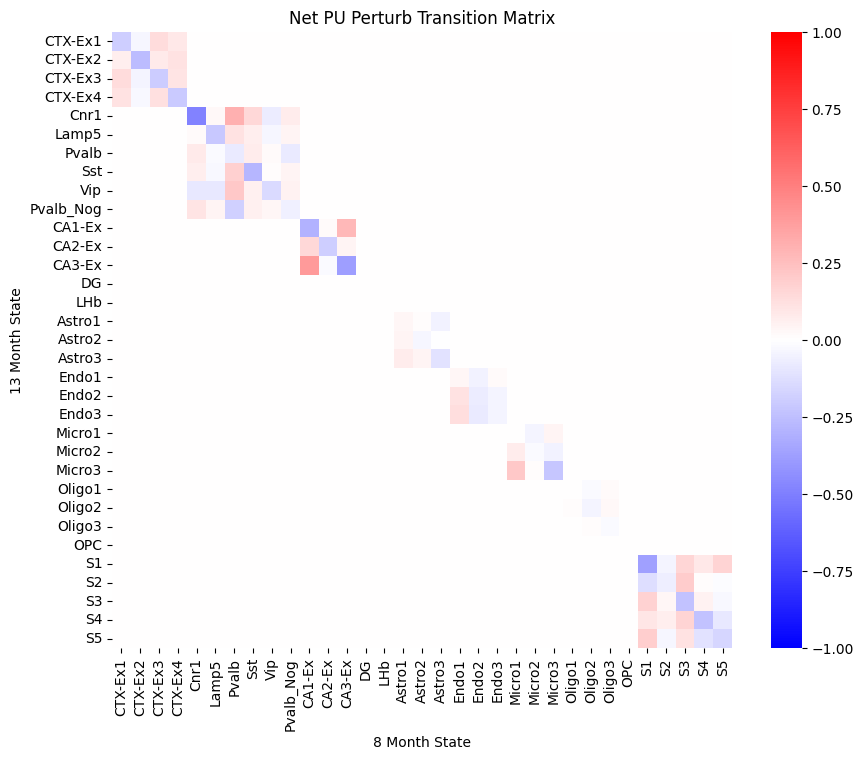

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

net_PU = DONEPEZIL_param- dis_transmat_param

plt.figure(figsize=(10, 8))  # Adjust size as necessary
sns.heatmap(net_PU, cmap="bwr", cbar=True, vmin = -1, vmax = 1, xticklabels=True, yticklabels=True)

# Add labels
plt.title("Net PU Perturb Transition Matrix")
plt.xlabel("8 Month State")
plt.ylabel("13 Month State")

# Show the plot
plt.show()

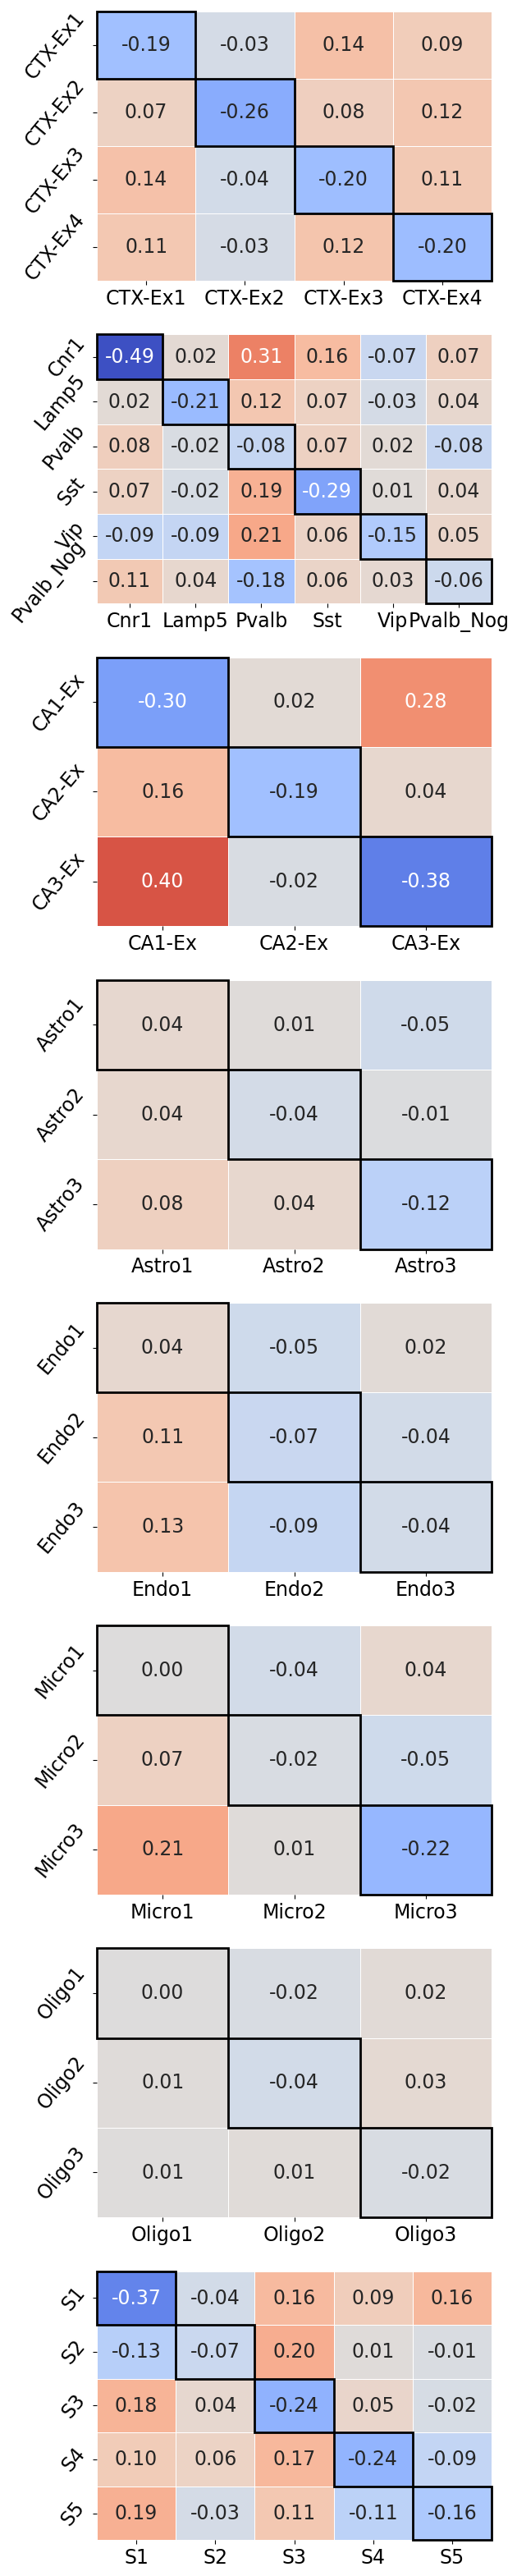

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import label
import matplotlib.gridspec as gridspec

# Function to extract connected components (submatrices with no zeros)
def extract_connected_components(matrix):
    labeled_matrix, num_components = label(matrix != 0)  # Find connected components of non-zero values
    components = []

    for label_id in range(1, num_components + 1):
        component_mask = labeled_matrix == label_id
        component_matrix = matrix * component_mask  # Get submatrix of non-zero values
        component_matrix = component_matrix[component_matrix != 0]  # Remove zeros
        components.append(component_matrix)

    return components

# Example DataFrame (trans)
trans = DONEPEZIL_param - dis_transmat_param # Replace with your DataFrame
trans = trans.drop(index=['DG', 'LHb', "OPC"], columns=['DG', 'LHb', "OPC"])

# Extract connected components
components = extract_connected_components(trans.to_numpy())

# **Define figure with 2 columns (main matrix + stability)**
fig = plt.figure(figsize=(7, 5 * len(components)))
gs = gridspec.GridSpec(len(components), 2, width_ratios=[2.5, 0.25], wspace=0.05)  # Stability column is narrower

plt.rcParams.update({'font.size': 17})

s = 0  # Start index for row labels

for index, component in enumerate(components):
    if len(component) == 1:
        continue  # Skip single-value components

    # Reshape component to nearest square/rectangle
    size = int(np.sqrt(len(component)))
    reshaped_component = component[:size*size].reshape((size, size))
    N = reshaped_component.shape[0]

    # Extract labels
    component_indices = list(trans.index[s:s+size])

    # # Compute stability column
    # stability = [
    #     reshaped_component[row, row] - (np.sum(reshaped_component[row]) - reshaped_component[row, row])
    #     for row in range(size)
    # ]

    # print(component_indices)
    # print(np.mean(np.abs(stability)))

    # stability_column = np.array(stability).reshape(-1, 1)

    # **Create subplot for main transition matrix**
    ax_matrix = plt.subplot(gs[index, 0])
    sns.heatmap(reshaped_component, annot=True, cmap='coolwarm', cbar=False,
                ax=ax_matrix, linewidths=0.5, vmin=-.5, vmax=.5, fmt=".2f",
                yticklabels=component_indices, xticklabels=component_indices)

    ax_matrix.set_xticklabels(ax_matrix.get_xticklabels(), rotation=0)
    ax_matrix.set_yticklabels(ax_matrix.get_yticklabels(), rotation=50)


    # **Create subplot for stability column**
    # ax_stability = plt.subplot(gs[index, 1])
    # sns.heatmap(stability_column, annot=False, cmap='coolwarm', cbar=False,
    #             ax=ax_stability, linewidths=0.5, vmin=-1, vmax=1,
    #             yticklabels=[], xticklabels=[])

    # ax_stability.set_xticklabels(ax_stability.get_xticklabels(), rotation=0)
    for i in range(N):
        rect = patches.Rectangle(
            (i, i), 1, 1, fill=False, edgecolor='black', linewidth=2, clip_on = False
        )
        ax_matrix.add_patch(rect)
    s += size  # Move to next set of row labels
plt.savefig('donepezil_transmat.png', dpi = 800, bbox_inches = 'tight')
plt.show()


In [ ]:
trans = param_transmat

<ipython-input-23-7cbbf6848c29>:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_edge = cm.get_cmap("Reds")


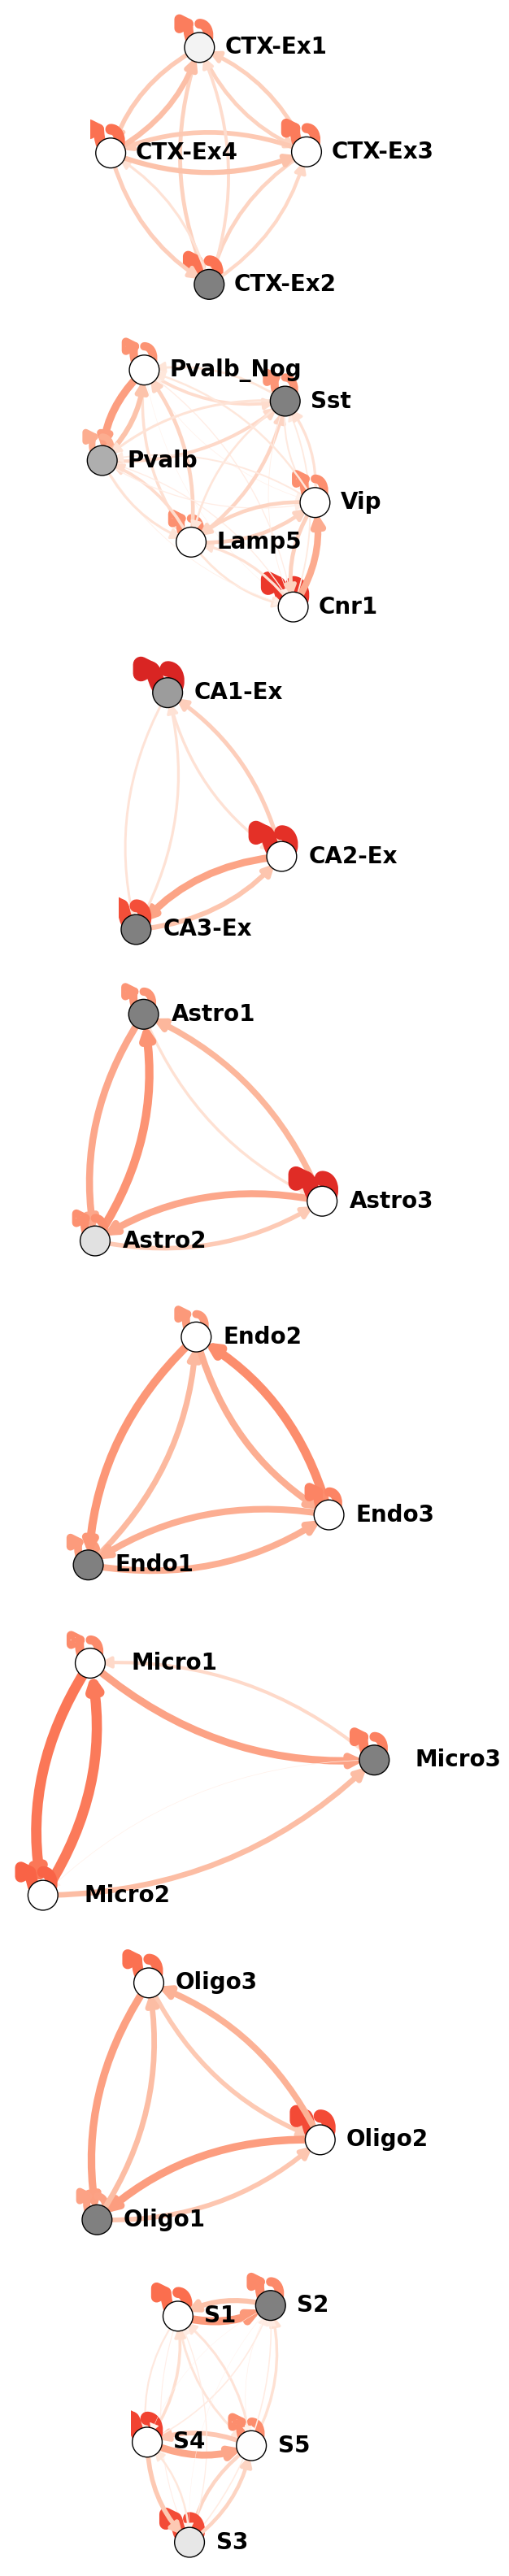

In [ ]:
trans = con_transmat_param
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# Create graph
G = nx.DiGraph()

# Add nodes
for node in trans.index:
    G.add_node(node)

# Normalize weights for colormap (bwr for edge weights)
norm_edge = mcolors.Normalize(vmin=0, vmax=1)
cmap_edge = cm.get_cmap("Reds")

# Normalize stability scores for colormap (Reds for stability scores)
# Colorbar for stability scores (Reds colormap)
colors = [(1, 1, 1), (0.5, 0.5, 0.5)]  # White to middle gray
n_bins = 100  # Number of bins to divide the colormap into
cmap_stability = mcolors.LinearSegmentedColormap.from_list("WhiteToGray", colors, N=n_bins)

# Normalize stability scores for colormap
norm_stability = mcolors.Normalize(vmin=0, vmax=1)  # Stability scores between 0 and 1

# Use the custom colormap
sm_stability = cm.ScalarMappable(cmap=cmap_stability, norm=norm_stability)
sm_stability.set_array([])  # Empty array just for colorbar
cmap_stability = sm_stability.get_cmap()

# Add edges with weights, including self-loops
edges, colors, widths = [], [], []
for i, row in trans.iterrows():
    for j, weight in row.items():
        if weight != 0:  # Include all connections, even self-loops
            G.add_edge(i, j, weight=weight)
            edges.append((i, j))
            colors.append(cmap_edge(norm_edge(weight)))  # Map color from colormap
            widths.append(abs(weight) * 10)  # Scale width

# Find connected components (subgraphs)
subgraphs = [sg for sg in nx.weakly_connected_components(G) if len(sg) > 1]
num_subgraphs = len(subgraphs)

# Define subplot grid as a vertical column
fig, axes = plt.subplots(len(subgraphs), 1, figsize=(6, 4 * len(subgraphs)))  # Width x height
if len(subgraphs) == 1:
    axes = [axes]  # Ensure axes is iterable

# Plot each subgraph in its own row
for i, subgraph_nodes in enumerate(subgraphs):
    ax = axes[i]
    subG = G.subgraph(subgraph_nodes)
    pos = nx.spring_layout(subG, seed=42)

    # Compute stability scores
    stability_scores = {}
    max_stability = 0
    for node in subG.nodes():
        in_edges = sum(abs(subG[u][node]["weight"]) for u in subG.predecessors(node))
        out_edges = sum(abs(subG[node][v]["weight"]) for v in subG.successors(node))
        stability_scores[node] = in_edges - out_edges
        max_stability = max(max_stability, stability_scores[node])

    # Normalize stability scores
    stability_scores_norm = {
        node: score / max_stability if max_stability != 0 else 0
        for node, score in stability_scores.items()
    }

    # Prepare edge visuals
    sub_edges = list(subG.edges())
    sub_colors = [cmap_edge(norm_edge(G[u][v]['weight'])) for u, v in sub_edges]
    sub_widths = [abs(G[u][v]['weight']) * 20 for u, v in sub_edges]

    # Draw
    node_colors = [cmap_stability(stability_scores_norm[node]) for node in subG.nodes()]
    nx.draw_networkx_nodes(subG, pos, node_size=700, node_color=node_colors, edgecolors="black", ax=ax)
    nx.draw_networkx_edges(subG, pos, edgelist=sub_edges, edge_color=sub_colors, width=sub_widths,
                           connectionstyle="arc3,rad=0.2", arrowsize=20, ax=ax)
    label_offset = 0.2  # adjust spacing as needed
    for node, (x, y) in pos.items():
        ax.text(
            x + label_offset, y,
            node,
            fontsize=20,
            fontweight='bold',
            verticalalignment='center',
            horizontalalignment='left',
            clip_on=False  # prevents text from being cut off
        )
    ax.set_aspect('equal')  # Force square aspect
    ax.axis("off")

# Adjust layout
plt.tight_layout()
plt.savefig("directed_graph_transitions_CONTROL.png", bbox_inches="tight", dpi=600)
plt.show()


